<a href="https://colab.research.google.com/github/Juuphaada/Machine-Learning-Study/blob/main/mexico_dataVisualization_featureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Notebook introduction
*   Explore dataset
*   Visualize dataset
*   Perform QuartileTransformer to data
*   Select feature with filter method



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
csv_file_path = "/content/drive/MyDrive/Colab Notebooks/Researching/Hipertension_Arterial_Mexico.csv"
df = pd.read_csv(csv_file_path)

In [ ]:
print("Shape of the Hipertension_Arterial_Mexico.csv :", df.shape)

Shape of the Hipertension_Arterial_Mexico.csv : (4363, 36)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4363 entries, 0 to 4362
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   FOLIO_I                           4363 non-null   object 
 1   sexo                              4363 non-null   int64  
 2   edad                              4363 non-null   int64  
 3   concentracion_hemoglobina         4363 non-null   float64
 4   temperatura_ambiente              4363 non-null   int64  
 5   valor_acido_urico                 4363 non-null   float64
 6   valor_albumina                    4363 non-null   float64
 7   valor_colesterol_hdl              4363 non-null   int64  
 8   valor_colesterol_ldl              4363 non-null   float64
 9   valor_colesterol_total            4363 non-null   int64  
 10  valor_creatina                    4363 non-null   float64
 11  resultado_glucosa                 4363 non-null   float64
 12  valor_

In [ ]:
df.head(10)

,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_01001004,2,41,14.2,22,4.8,4.0,34,86.0,139,...,64.70,154.0,48.5,33.5,222.2,107,4,32.889389,120,1
1,2022_01001009,2,65,14.1,9,4.4,3.8,73,130.0,252,...,96.75,152.2,44.5,41.1,113.7,104,2,1.000000,240,0
2,2022_01001012,2,68,14.2,22,4.8,4.0,34,86.0,139,...,68.70,144.8,42.3,37.8,103.7,105,1,1.000000,480,0
3,2022_01001013,1,35,15.7,11,6.5,4.1,49,107.0,203,...,64.70,154.0,48.5,33.5,222.2,117,5,26.265339,275,1
4,2022_01001015,2,65,12.7,7,4.2,4.2,41,76.0,145,...,97.15,161.3,49.6,42.0,118.9,123,2,1.000000,255,0
5,2022_01001017,2,70,14.2,22,4.8,4.0,34,86.0,139,...,96.00,150.0,47.5,41.0,222.2,149,3,1.000000,775,0
6,2022_01001024,2,30,13.8,15,4.6,3.8,42,84.0,139,...,64.70,154.0,48.5,33.5,222.2,119,2,39.031773,300,1
7,2022_01001034,2,29,14.2,22,4.8,4.0,34,86.0,139,...,64.70,154.0,48.5,33.5,222.2,113,3,24.741058,600,1
8,2022_01001036,1,58,14.2,22,4.8,4.0,34,86.0,139,...,64.70,154.0,48.5,33.5,222.2,102,4,25.411527,740,1
9,2022_01001041,2,62,14.5,9,4.4,3.8,44,133.0,236,...,102.45,134.2,48.2,39.6,134.2,111,2,1.000000,150,1


In [ ]:
# get ID ('FOLIO_I'), non-linear regression feature ('sexo'), and target (riesgo_hipertension) out
columns = df.drop(columns=['FOLIO_I','sexo','riesgo_hipertension']).columns.to_list()

In [ ]:
# check number of samples in each class
target_class = df['riesgo_hipertension'].unique().tolist()

for i in  target_class:
  n = df[df['riesgo_hipertension'] == i].shape[0]
  print(f'riesgo_hipertension = {i} : {n}')

riesgo_hipertension = 1 : 2816
riesgo_hipertension = 0 : 1547


# Visualize dataset

<Axes: >

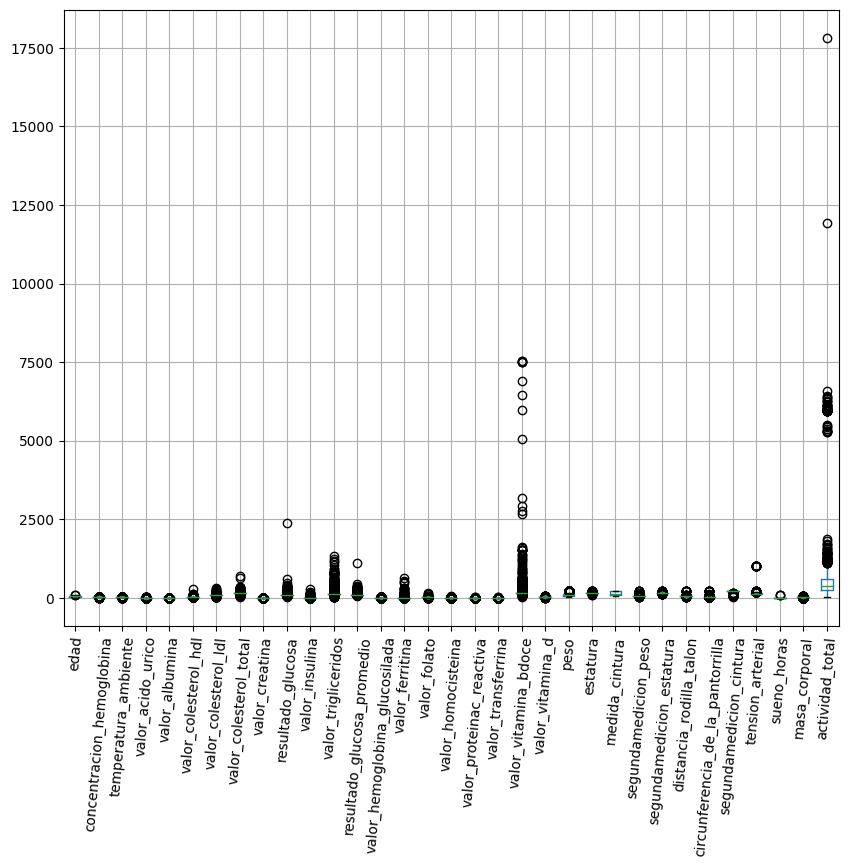

In [ ]:
df.boxplot(column=columns, figsize=(10, 8), rot=85)

In [ ]:
# do StandardScaler for reducing scale of data for ploting
df_standardized = df.copy()
df_standardized[columns] = StandardScaler().fit_transform(df[columns])
df_standardized['sexo'] = df_standardized['sexo'].replace(1, 0)
df_standardized['sexo'] = df_standardized['sexo'].replace(2, 1)
df_standardized.head(10)

,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_01001004,1,-0.437250,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.316383,0.273591,0.847662,-0.537116,1
1,2022_01001009,1,1.224349,-0.111850,-3.912665,-0.472192,-0.152977,4.574424,2.407022,3.821440,...,3.356803,-0.392370,-0.464702,0.564477,-1.716019,-0.356993,-0.446359,-1.742209,-0.358976,0
2,2022_01001012,1,1.432049,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,0.285488,-1.824543,-0.683624,0.270003,-1.919873,-0.343456,-0.806335,-1.742209,-0.002695,0
3,2022_01001013,0,-0.852650,1.279950,-3.280875,2.088088,0.512466,1.604802,1.094843,2.085406,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.181016,0.633566,0.309695,-0.307018,1
4,2022_01001015,1,1.224349,-1.329674,-4.544454,-0.716028,0.734281,0.614928,-0.673746,0.030508,...,3.400601,1.368815,0.042799,0.644788,-1.610014,-0.099796,-0.446359,-1.742209,-0.336708,0
5,2022_01001017,1,1.570515,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,3.274682,-0.818151,-0.166172,0.555554,0.495799,0.252159,-0.086384,-1.742209,0.435234,0
6,2022_01001024,1,-1.198817,-0.372812,-2.017296,-0.228355,-0.152977,0.738662,-0.217336,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.153942,-0.446359,1.346511,-0.269905,1
7,2022_01001034,1,-1.268050,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.235163,-0.086384,0.185902,0.175446,1
8,2022_01001036,0,0.739716,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.384067,0.273591,0.240354,0.383276,1
9,2022_01001041,1,1.016649,0.236100,-3.912665,-0.472192,-0.152977,0.986131,2.578176,3.254572,...,3.980920,-3.876033,-0.096515,0.430625,-1.298118,-0.262236,-0.446359,-1.742209,-0.492581,1


### Plot box
*   devided by target
*   devided by sex



,0
actividad_total,"Axes(0.125,0.712609;0.0731132x0.167391)"
circunferencia_de_la_pantorrilla,"Axes(0.212736,0.712609;0.0731132x0.167391)"
concentracion_hemoglobina,"Axes(0.300472,0.712609;0.0731132x0.167391)"
distancia_rodilla_talon,"Axes(0.388208,0.712609;0.0731132x0.167391)"
edad,"Axes(0.475943,0.712609;0.0731132x0.167391)"
estatura,"Axes(0.563679,0.712609;0.0731132x0.167391)"
masa_corporal,"Axes(0.651415,0.712609;0.0731132x0.167391)"
medida_cintura,"Axes(0.739151,0.712609;0.0731132x0.167391)"
peso,"Axes(0.826887,0.712609;0.0731132x0.167391)"
resultado_glucosa,"Axes(0.125,0.511739;0.0731132x0.167391)"


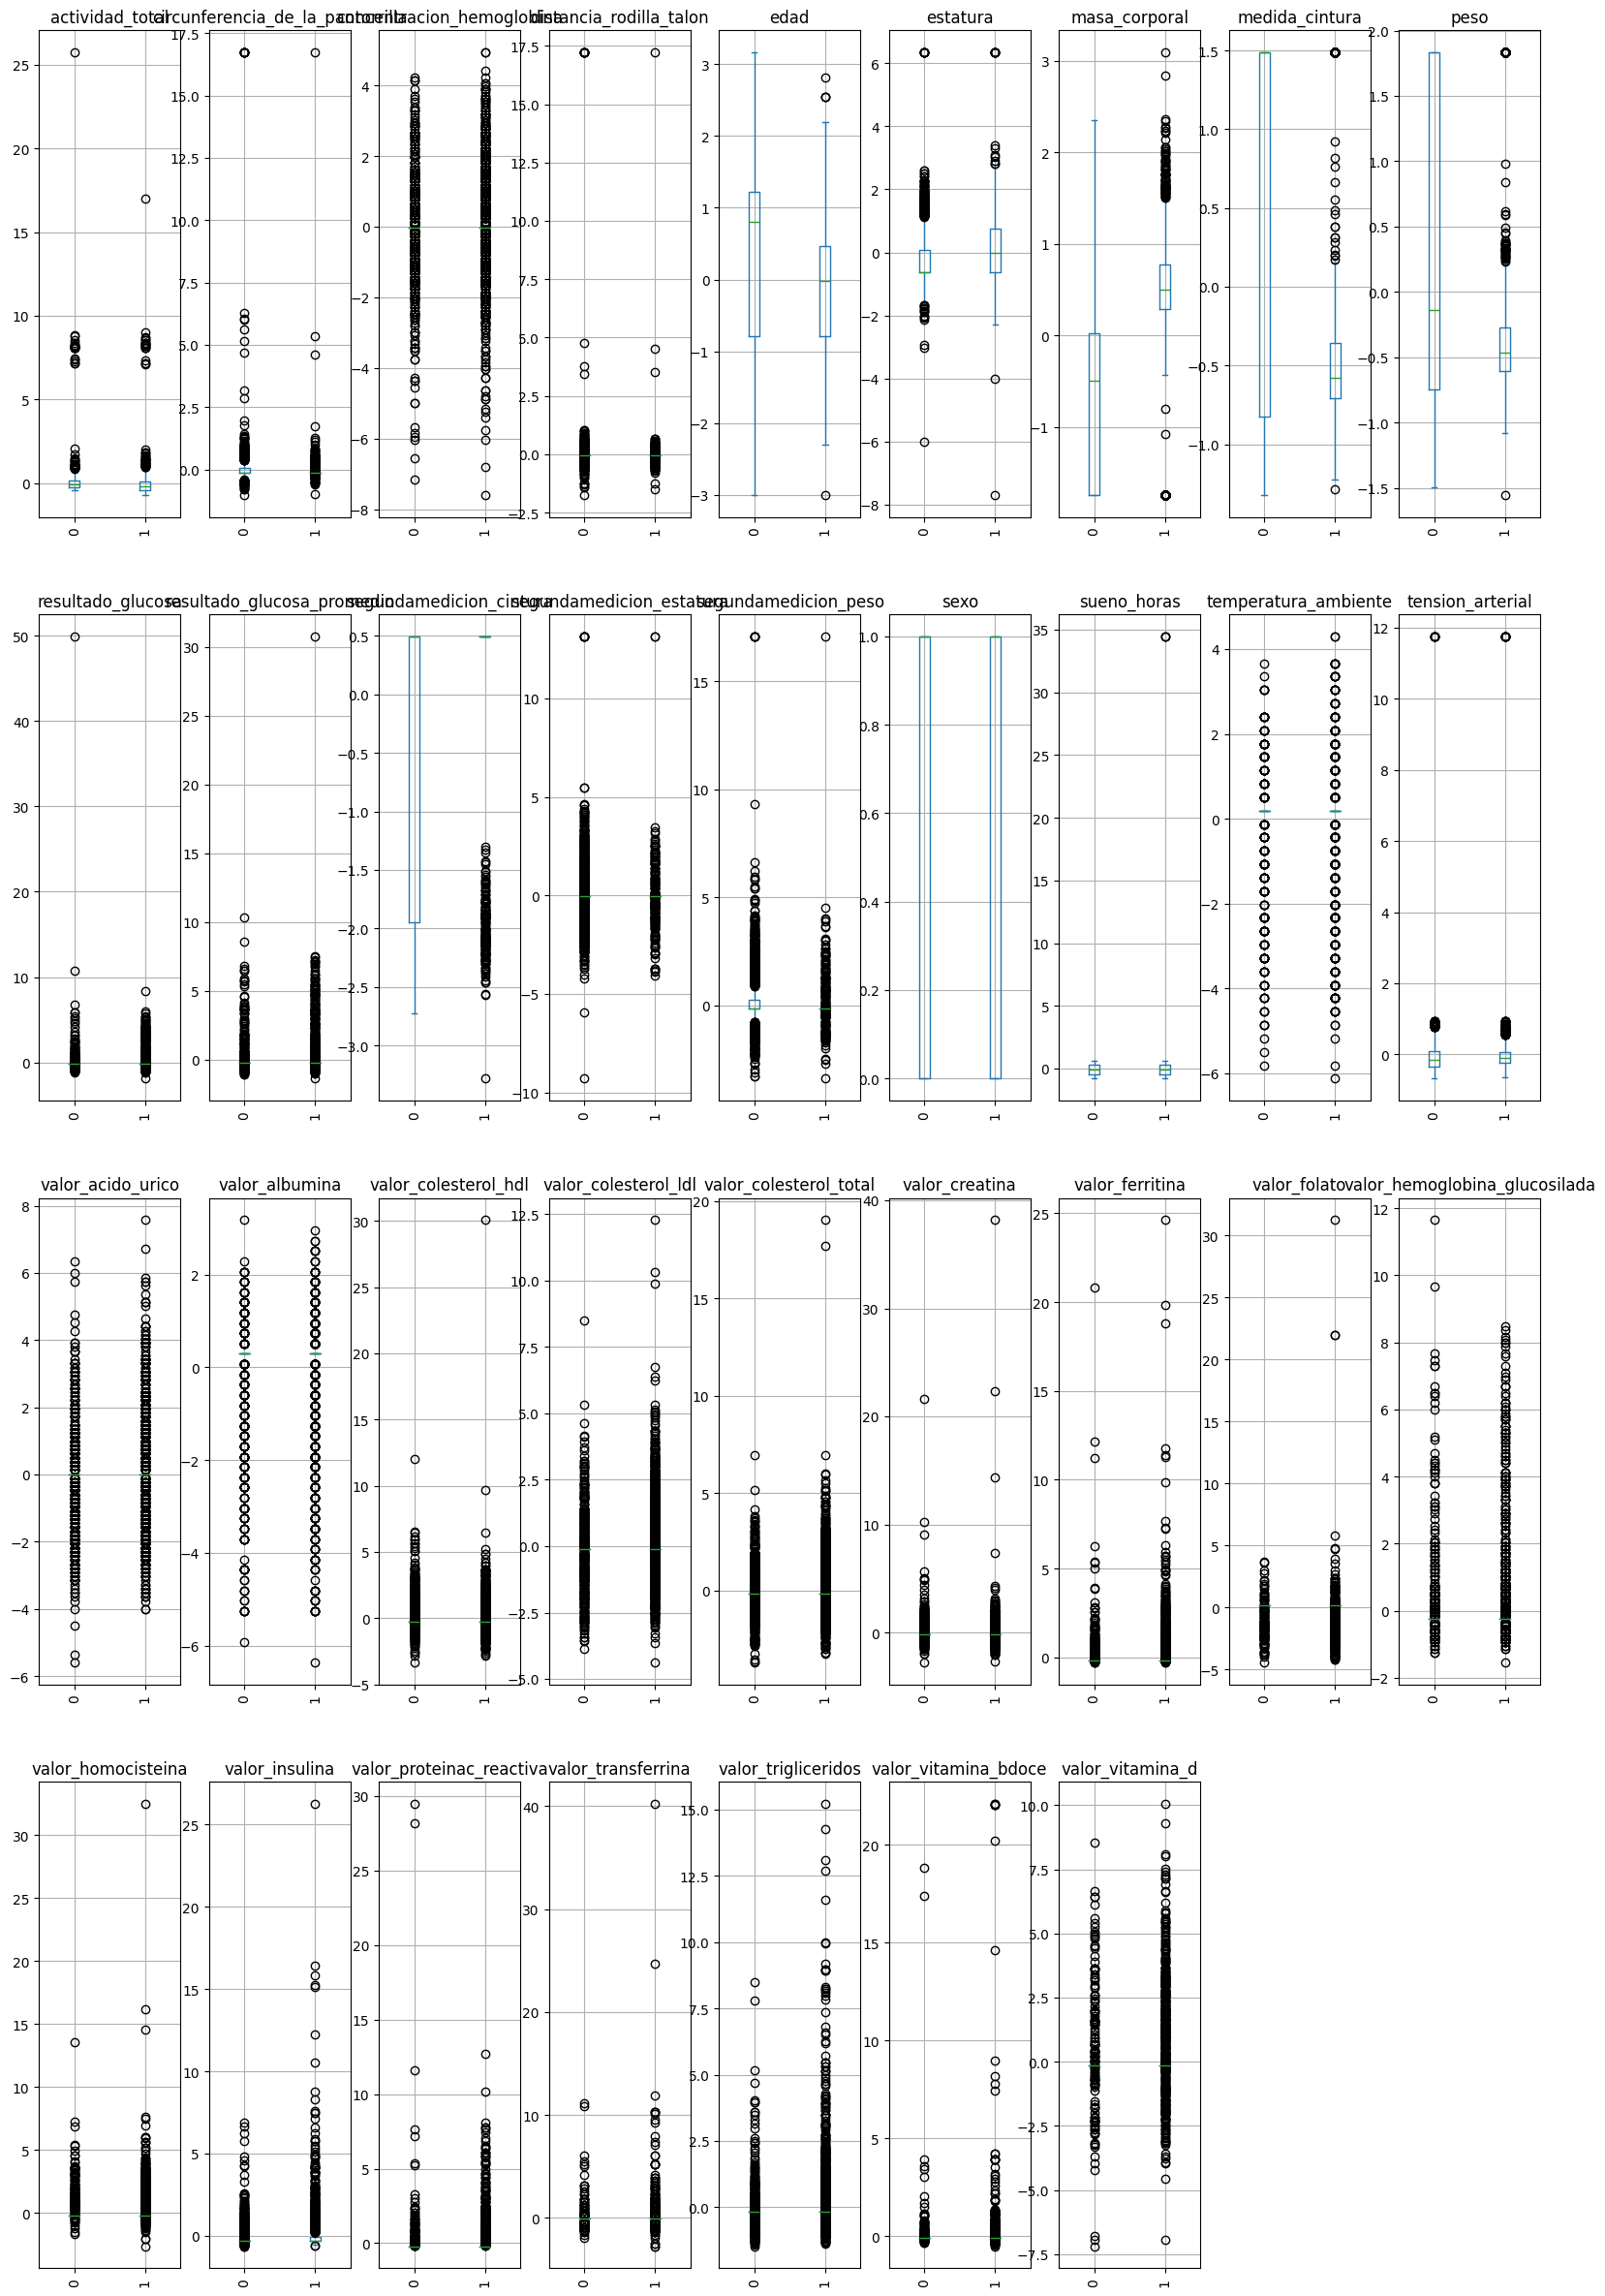

In [ ]:
# devided by target
df_std_with_target = df_standardized
df_std_with_target.plot.box(by='riesgo_hipertension',figsize=(20, 30), rot=90, grid= True, layout = (4,9))

,0
actividad_total,"Axes(0.125,0.712609;0.0731132x0.167391)"
circunferencia_de_la_pantorrilla,"Axes(0.212736,0.712609;0.0731132x0.167391)"
concentracion_hemoglobina,"Axes(0.300472,0.712609;0.0731132x0.167391)"
distancia_rodilla_talon,"Axes(0.388208,0.712609;0.0731132x0.167391)"
edad,"Axes(0.475943,0.712609;0.0731132x0.167391)"
estatura,"Axes(0.563679,0.712609;0.0731132x0.167391)"
masa_corporal,"Axes(0.651415,0.712609;0.0731132x0.167391)"
medida_cintura,"Axes(0.739151,0.712609;0.0731132x0.167391)"
peso,"Axes(0.826887,0.712609;0.0731132x0.167391)"
resultado_glucosa,"Axes(0.125,0.511739;0.0731132x0.167391)"


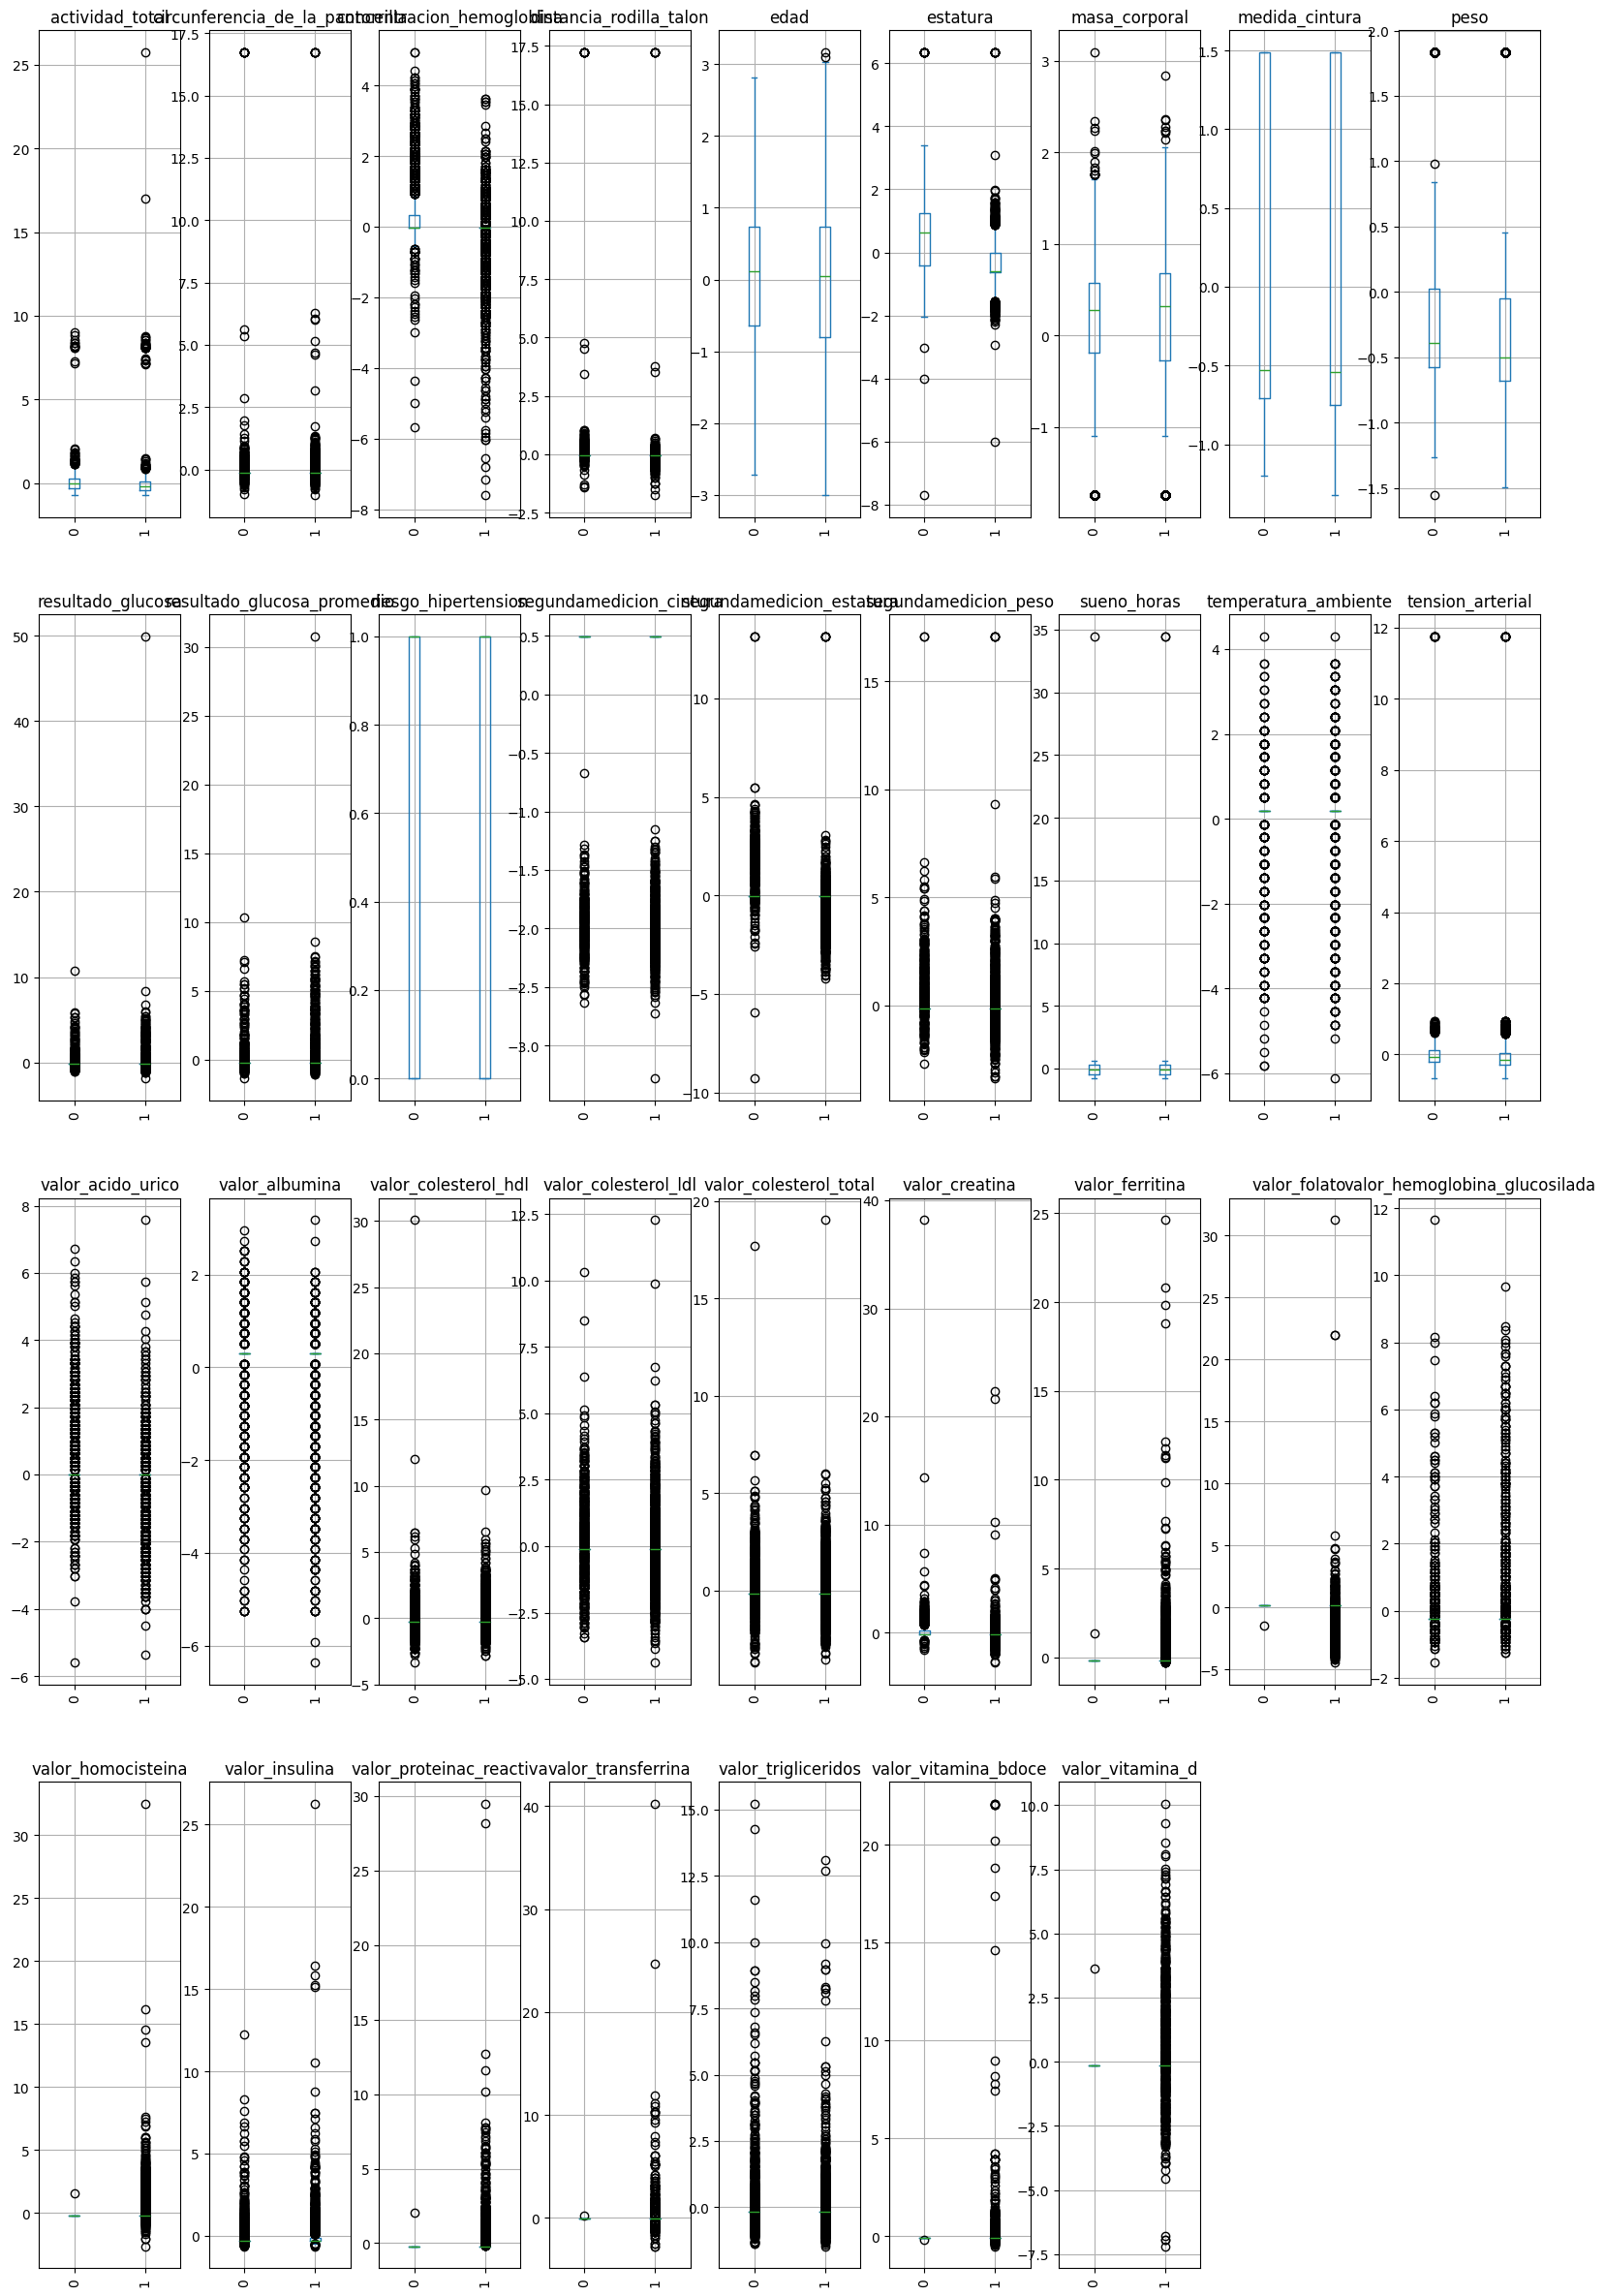

In [ ]:
# devided by sex
df_std_with_sex = df_standardized
df_std_with_sex.plot.box(by='sexo',figsize=(20, 30), rot=90, grid= True, layout = (4,9))

there is a lot of outline

### Plot graph
for see distribution shape of each features



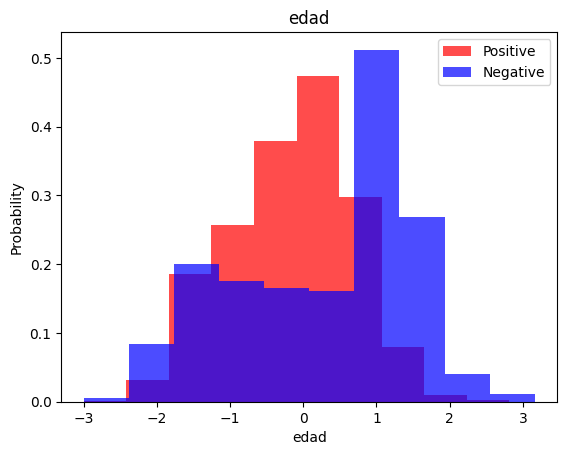

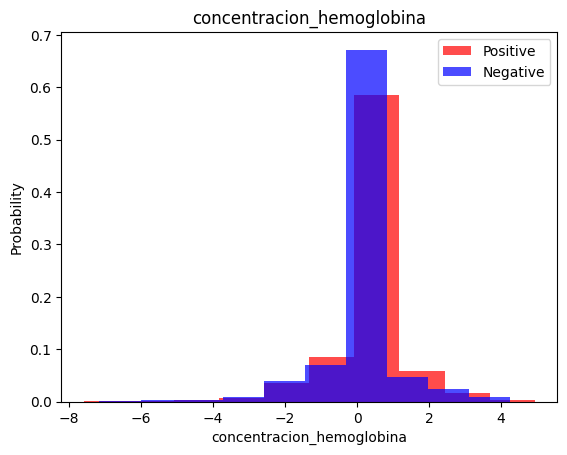

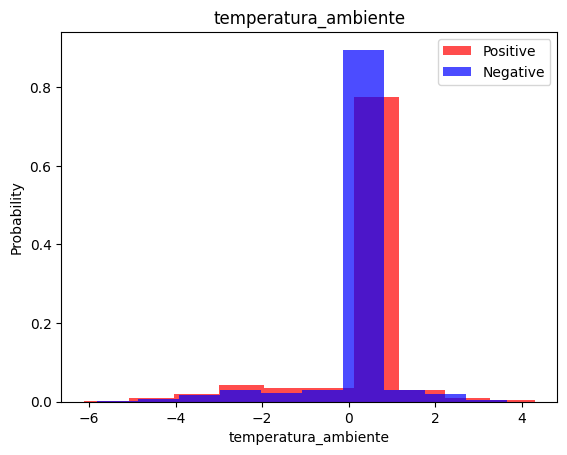

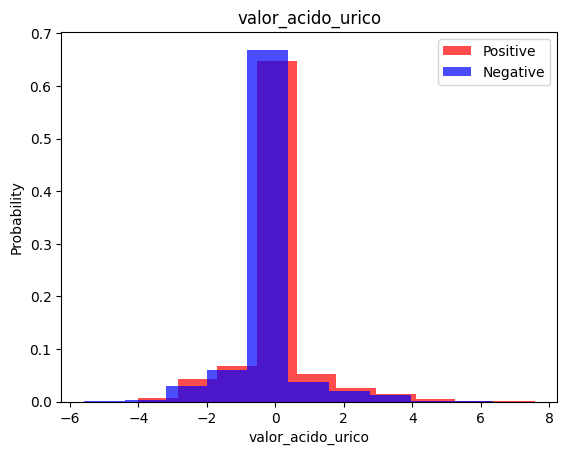

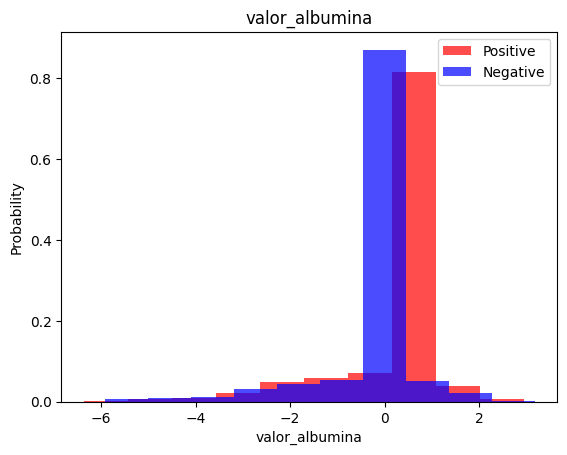

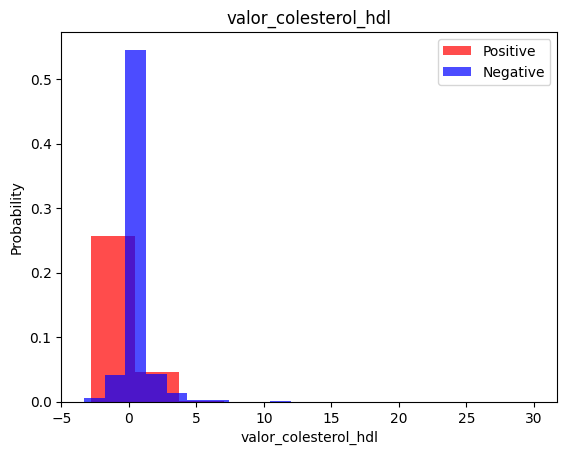

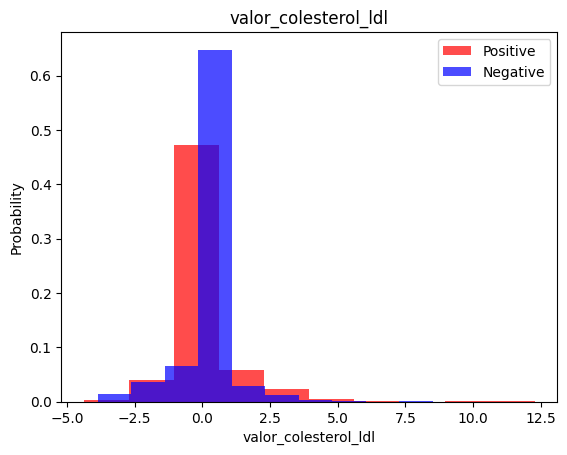

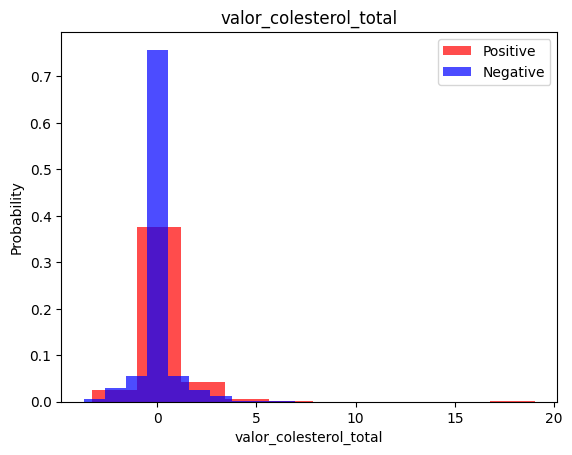

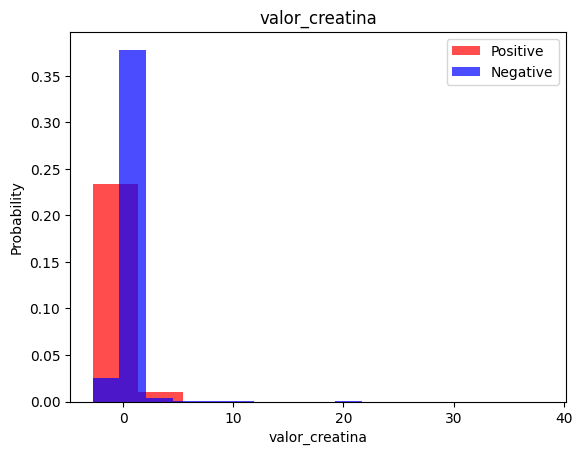

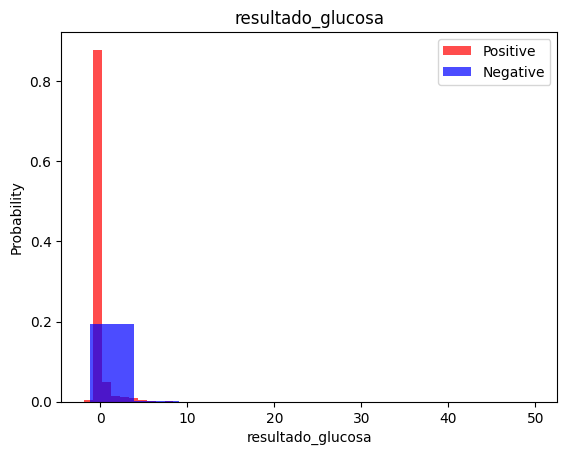

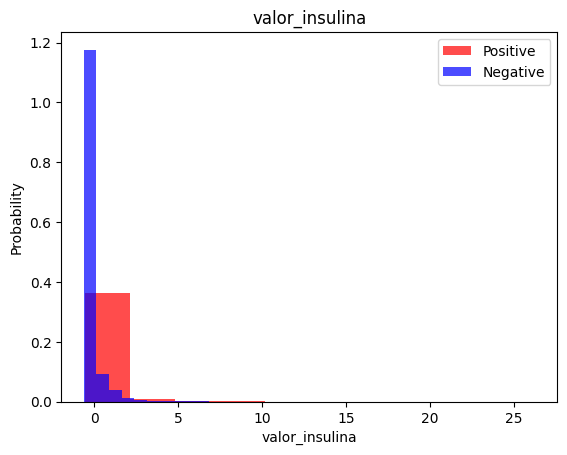

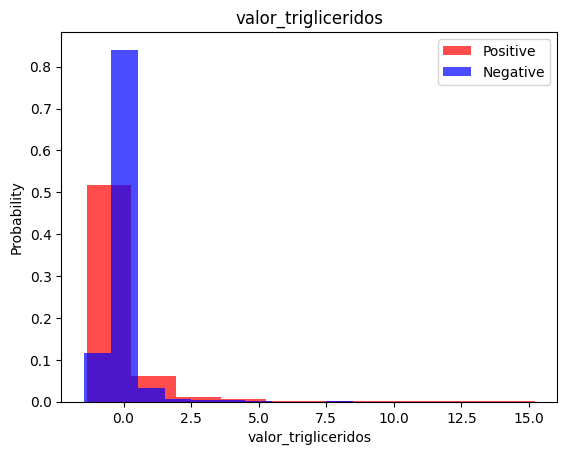

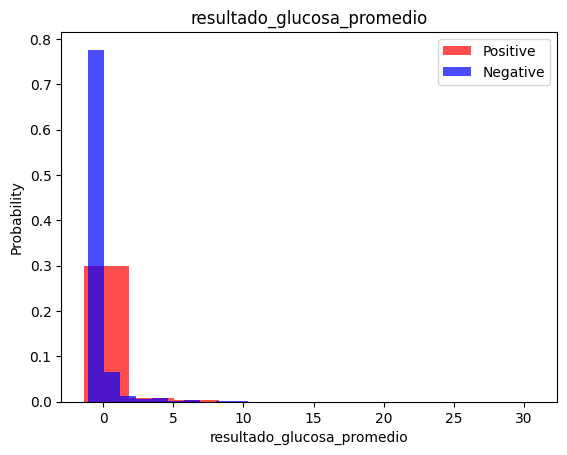

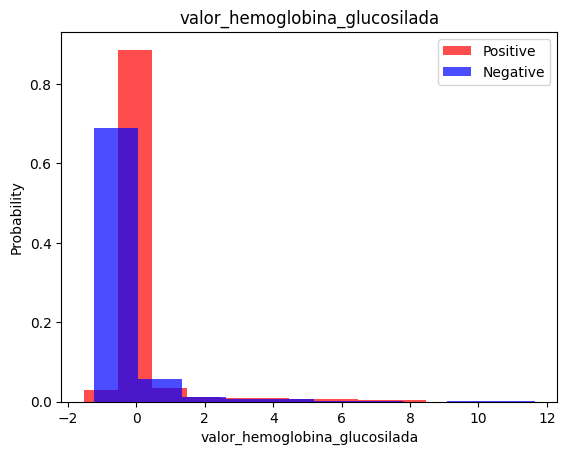

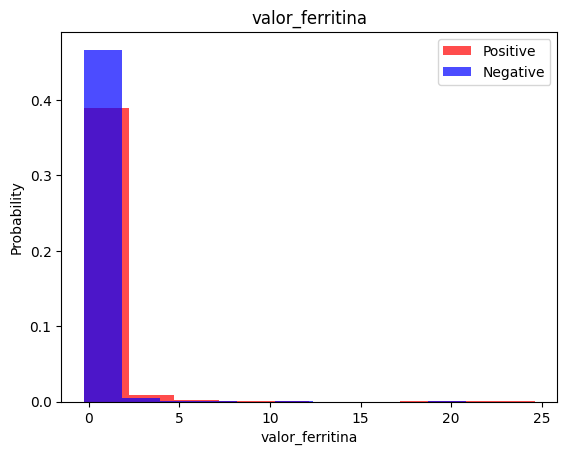

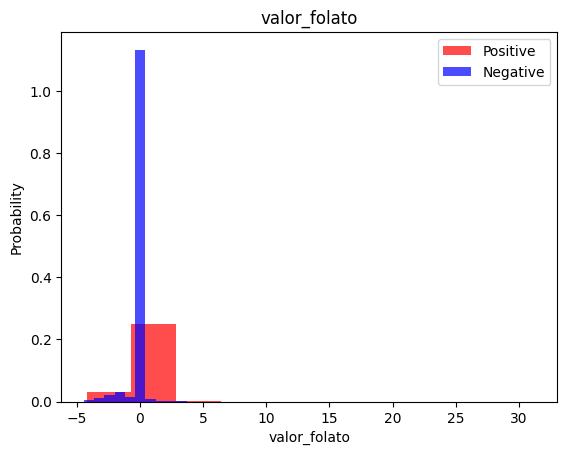

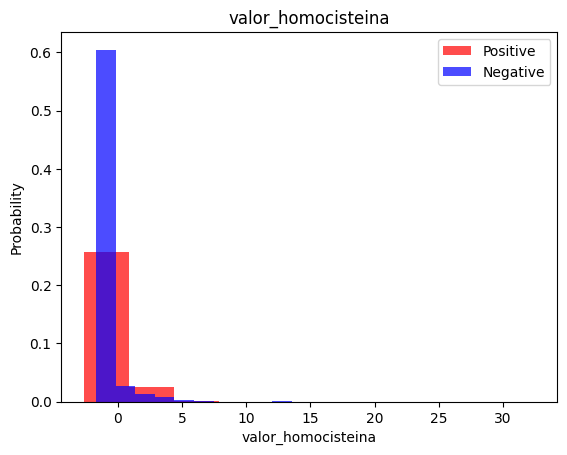

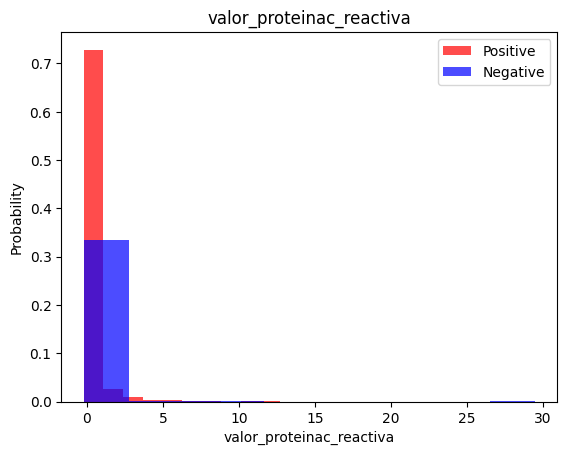

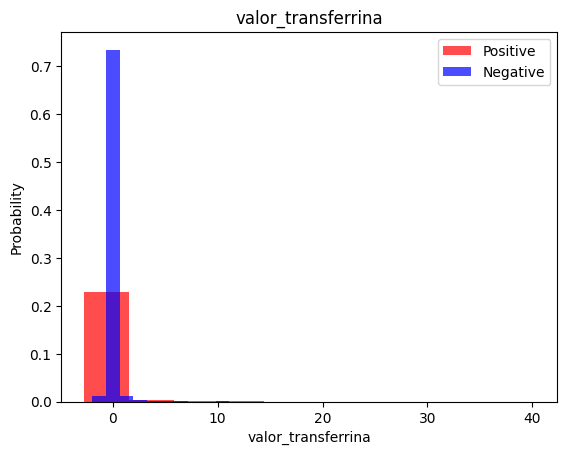

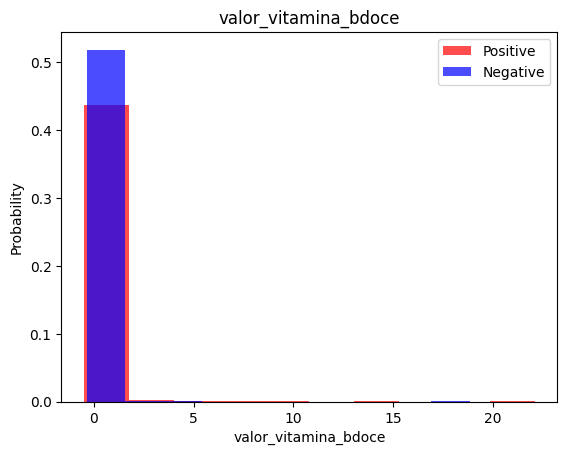

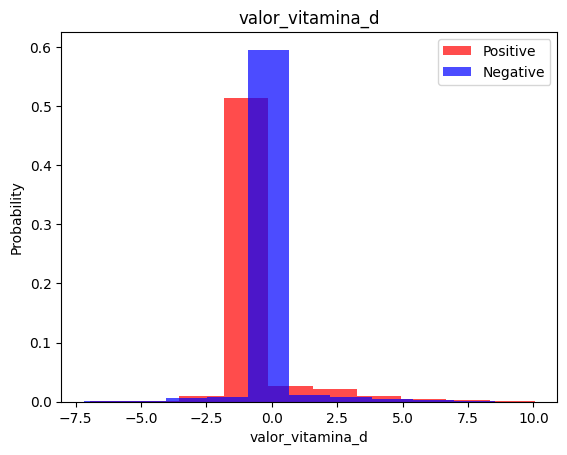

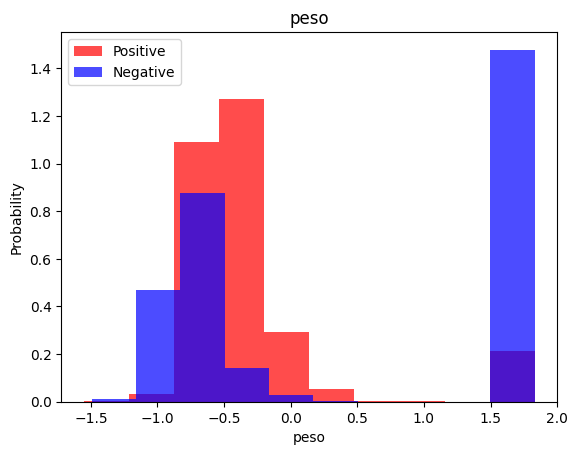

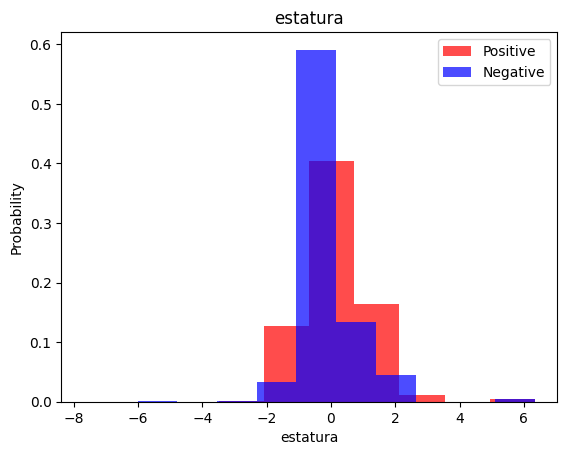

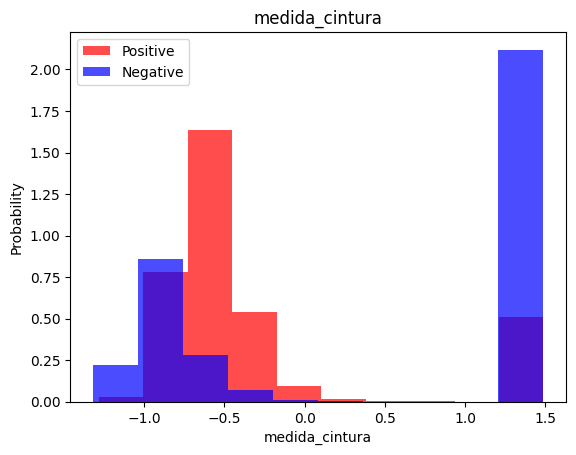

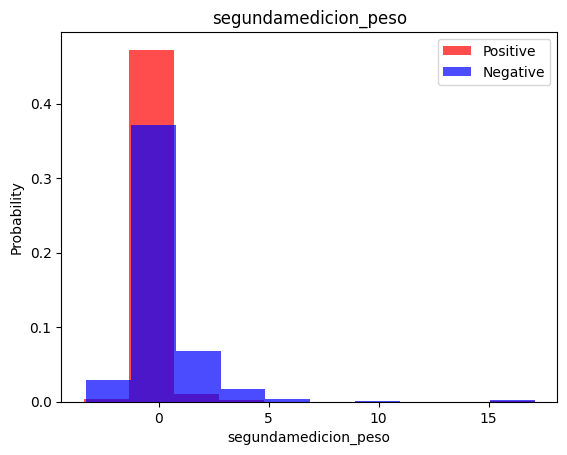

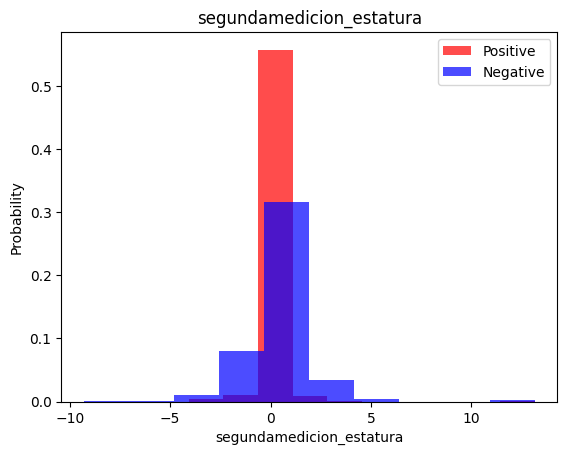

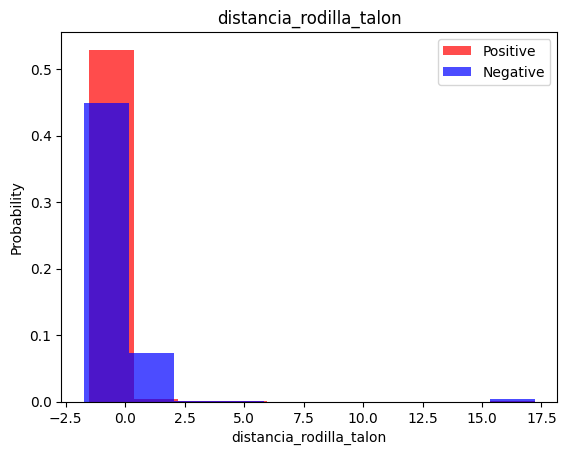

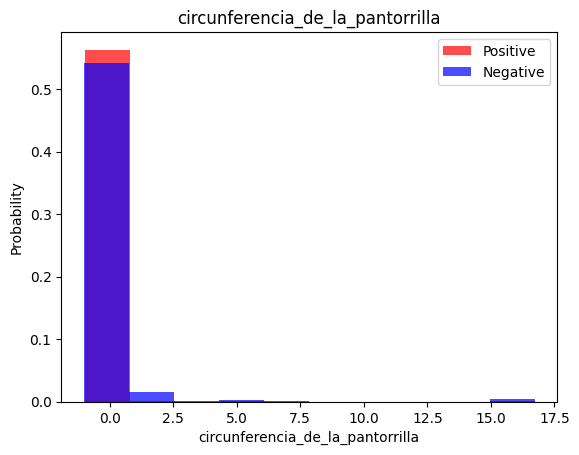

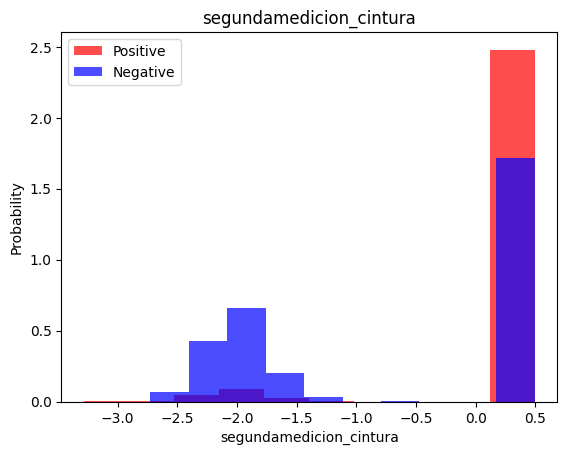

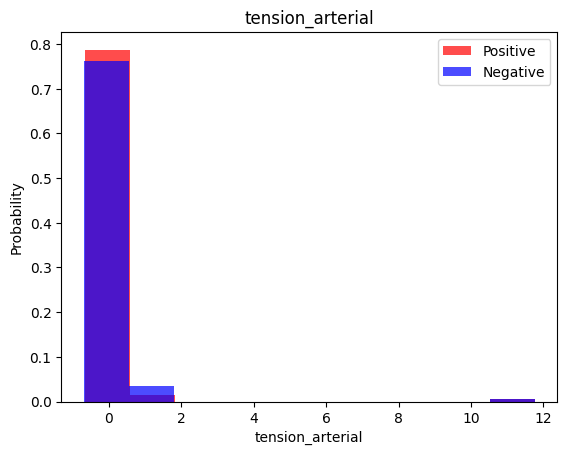

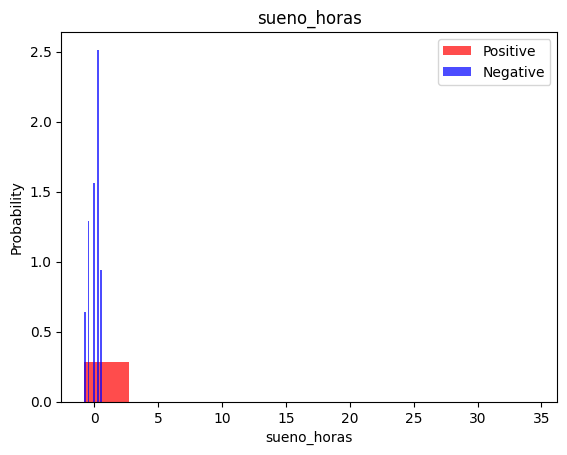

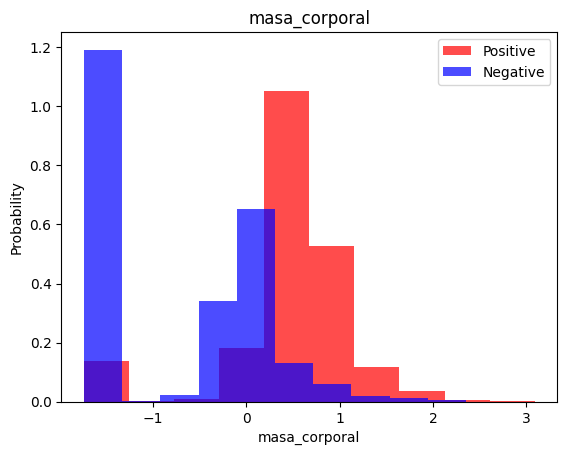

In [ ]:
for col in columns[:-1]:
  plt.hist(df_std_with_target[df_std_with_target["riesgo_hipertension"]==1][col], color='red', label='Positive', alpha=0.7, density=True)
  plt.hist(df_std_with_target[df_std_with_target["riesgo_hipertension"]==0][col], color='blue', label='Negative', alpha=0.7, density=True)

  plt.title(col)
  plt.ylabel("Probability")
  plt.xlabel(col)
  plt.legend()
  plt.show()

The majority of the data is skewed and not normally distributed, which may degrade the performance of distance and distribution-sensitive models such as KNN and SVM.

### Identify outline
see how much outline data for each feature

In [ ]:
# find Quantiles, IQR, Min, Max of each features
columns_Q = {}
for col in columns :
  Quantiles = df_standardized[f'{col}'].quantile([0.25, 0.5, 0.75])
  Quantiles = Quantiles.squeeze().tolist()
  Q1 = Quantiles[0]
  Q2 = Quantiles[1]
  Q3 = Quantiles[2]
  IQR = Q3 - Q1
  columns_Q.update({f'{col}' :
                    { 'Q1' : Q1,
                      'Q2' : Q2,
                      'Q3' : Q3,
                      'Min' : Q2 + 1.5*IQR,
                      'Max' : Q3 + 1.5*IQR,
                      'IQR' : IQR
                    }
                  })
  print(f'{col} :' ,columns_Q[f'{col}'])


edad : {'Q1': -0.7834169117997815, 'Q2': 0.04738267973737397, 'Q3': 0.7397156726850035, 'Min': 2.3320815564645514, 'Max': 3.0244145494121812, 'IQR': 1.523132584484785}
concentracion_hemoglobina : {'Q1': -0.024862100146312887, 'Q2': -0.024862100146312887, 'Q3': -0.024862100146312887, 'Min': -0.024862100146312887, 'Max': -0.024862100146312887, 'IQR': 0.0}
temperatura_ambiente : {'Q1': 0.19396795638194272, 'Q2': 0.19396795638194272, 'Q3': 0.19396795638194272, 'Min': 0.19396795638194272, 'Max': 0.19396795638194272, 'IQR': 0.0}
valor_acido_urico : {'Q1': 0.015480773120890516, 'Q2': 0.015480773120890516, 'Q3': 0.015480773120890516, 'Min': 0.015480773120890516, 'Max': 0.015480773120890516, 'IQR': 0.0}
valor_albumina : {'Q1': 0.29065180128836493, 'Q2': 0.29065180128836493, 'Q3': 0.29065180128836493, 'Min': 0.29065180128836493, 'Max': 0.29065180128836493, 'IQR': 0.0}
valor_colesterol_hdl : {'Q1': -0.2512120371744196, 'Q2': -0.2512120371744196, 'Q3': -0.2512120371744196, 'Min': -0.25121203717441

In [ ]:
# try comparing with value from describe()
df_standardized[columns].describe()

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,medida_cintura,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total
count,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,...,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03,4.363000e+03
mean,1.001567e-16,-1.306109e-15,2.279990e-17,-4.103983e-16,4.690266e-16,3.550271e-16,5.862833e-17,-3.257129e-16,-3.322272e-16,-2.752274e-16,...,-2.784845e-16,-5.447549e-16,5.366120e-16,-9.445675e-17,-2.255562e-16,-1.433137e-16,-5.618548e-17,-7.654254e-17,1.498279e-16,-3.257129e-17
std,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,...,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.998882e+00,-7.592770e+00,-6.123928e+00,-5.592751e+00,-6.363785e+00,-3.344569e+00,-4.376373e+00,-3.689565e+00,-2.764753e+00,-1.897588e+00,...,-1.320805e+00,-3.404469e+00,-9.295065e+00,-1.738430e+00,-1.014976e+00,-3.283657e+00,-6.818743e-01,-8.063347e-01,-1.742209e+00,-7.004117e-01
25%,-7.834169e-01,-2.486210e-02,1.939680e-01,1.548077e-02,2.906518e-01,-2.512120e-01,-1.032336e-01,-1.820673e-01,-1.723572e-01,-1.073829e-01,...,-7.347421e-01,-1.524887e-01,-4.400379e-02,-6.666233e-02,-1.137061e-01,4.957987e-01,-2.622362e-01,-4.463594e-01,-2.300417e-01,-3.589757e-01
50%,4.738268e-02,-2.486210e-02,1.939680e-01,1.548077e-02,2.906518e-01,-2.512120e-01,-1.032336e-01,-1.820673e-01,-1.723572e-01,-1.073829e-01,...,-5.353775e-01,-1.524887e-01,-4.400379e-02,-6.666233e-02,-1.137061e-01,4.957987e-01,-1.268691e-01,-8.638416e-02,3.067683e-01,-1.511452e-01
75%,7.397157e-01,-2.486210e-02,1.939680e-01,1.548077e-02,2.906518e-01,-2.512120e-01,-1.032336e-01,-1.820673e-01,-1.723572e-01,-1.073829e-01,...,1.487486e+00,-1.524887e-01,-4.400379e-02,-6.666233e-02,-1.137061e-01,4.957987e-01,7.618163e-02,2.735911e-01,6.362231e-01,1.531782e-01
max,3.162881e+00,4.933422e+00,4.300600e+00,7.574401e+00,3.174241e+00,3.006368e+01,1.227689e+01,1.902060e+01,3.816519e+01,4.991304e+01,...,1.487486e+00,1.709505e+01,1.315521e+01,1.721822e+01,1.672487e+01,4.957987e-01,1.175837e+01,3.447124e+01,3.091131e+00,2.573861e+01


In [ ]:
# value of 'edad' column
columns_Q['edad']

{'Q1': -0.7834169117997815,
 'Q2': 0.04738267973737397,
 'Q3': 0.7397156726850035,
 'Min': 2.3320815564645514,
 'Max': 3.0244145494121812,
 'IQR': 1.523132584484785}

In [ ]:
# over-all data size
df_standardized.shape

(4363, 36)

In [ ]:
# outline data size for 'edad' column
df_standardized['edad'].to_frame().query(f'edad < {columns_Q['edad']['Min']} or edad > {columns_Q['edad']['Max']}').shape

(4337, 1)

In [ ]:
# collect outline sample for each column and size
outline = {}
for column in columns :
  outline_sample = df_standardized[f'{column}'].to_frame().query(f'{column} < {columns_Q[f'{column}']['Min']} or {column} > {columns_Q[f'{column}']['Max']}')
  outline.update({f'{column}':{ 'Feature' : column, 'Outlines': outline_sample.shape[0]}})
print(outline)

{'edad': {'Feature': 'edad', 'Outlines': 4337}, 'concentracion_hemoglobina': {'Feature': 'concentracion_hemoglobina', 'Outlines': 1521}, 'temperatura_ambiente': {'Feature': 'temperatura_ambiente', 'Outlines': 912}, 'valor_acido_urico': {'Feature': 'valor_acido_urico', 'Outlines': 1318}, 'valor_albumina': {'Feature': 'valor_albumina', 'Outlines': 1251}, 'valor_colesterol_hdl': {'Feature': 'valor_colesterol_hdl', 'Outlines': 1306}, 'valor_colesterol_ldl': {'Feature': 'valor_colesterol_ldl', 'Outlines': 1337}, 'valor_colesterol_total': {'Feature': 'valor_colesterol_total', 'Outlines': 1347}, 'valor_creatina': {'Feature': 'valor_creatina', 'Outlines': 1326}, 'resultado_glucosa': {'Feature': 'resultado_glucosa', 'Outlines': 1318}, 'valor_insulina': {'Feature': 'valor_insulina', 'Outlines': 4291}, 'valor_trigliceridos': {'Feature': 'valor_trigliceridos', 'Outlines': 1349}, 'resultado_glucosa_promedio': {'Feature': 'resultado_glucosa_promedio', 'Outlines': 1215}, 'valor_hemoglobina_glucosilad

now we explicitly see so many feature have overwhelming amount of outline compare to the sample amount

# Devide **Train&Test** Samples And Perform **QuantileTransformer**


In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split

X = df.drop(columns=['riesgo_hipertension'])
y = df['riesgo_hipertension']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
quantile_transformer = QuantileTransformer(output_distribution='normal', n_quantiles=1000)

# 'FOLIO_I','sexo' is binary feature, can't use quantileTransformer on
notTrans_columns = ['FOLIO_I','sexo']
X_train_transformed = quantile_transformer.fit_transform(X_train.drop(columns=notTrans_columns))
X_test_transformed = quantile_transformer.transform(X_test.drop(columns=notTrans_columns))


In [ ]:
# convert back to dataframe for ploting convenience
df_y_train = y_train.to_frame()
df_y_test = y_test.to_frame()

df_X_train_trans = pd.DataFrame(
    X_train_transformed,
    columns=X_train.drop(columns=notTrans_columns).columns,
    index=X_train.index
)

df_X_test_trans = pd.DataFrame(
    X_test_transformed,
    columns=X_test.drop(columns=notTrans_columns).columns,
    index=X_test.index
)

# put FOLIO_I','sexo' and 'riesgo_hipertension'back to the dataset
df_train_transformed = pd.concat([df_X_train_trans,X_train[notTrans_columns],df_y_train],axis=1)
df_train_transformed['sexo'] = df_train_transformed['sexo'].replace(1, 0)
df_train_transformed['sexo'] = df_train_transformed['sexo'].replace(2, 1)

df_test_transformed = pd.concat([df_X_test_trans,X_test[notTrans_columns],df_y_test],axis=1)

In [ ]:
df.shape

(4363, 36)

In [ ]:
# check number of samples in each class for both train set and test set
target_class = df['riesgo_hipertension'].unique().tolist()

for i in  target_class:
  n_train = df_y_train[df_y_train['riesgo_hipertension'] == i].shape[0]
  n_test = df_y_test[df_y_test['riesgo_hipertension'] == i].shape[0]
  print(f'Train-riesgo_hipertension = {i} : {n_train}')
  print(f'Test-riesgo_hipertension = {i} : {n_test}')

Train-riesgo_hipertension = 1 : 2252
Test-riesgo_hipertension = 1 : 564
Train-riesgo_hipertension = 0 : 1238
Test-riesgo_hipertension = 0 : 309


In [ ]:
df_train_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3490 entries, 3902 to 860
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   edad                              3490 non-null   float64
 1   concentracion_hemoglobina         3490 non-null   float64
 2   temperatura_ambiente              3490 non-null   float64
 3   valor_acido_urico                 3490 non-null   float64
 4   valor_albumina                    3490 non-null   float64
 5   valor_colesterol_hdl              3490 non-null   float64
 6   valor_colesterol_ldl              3490 non-null   float64
 7   valor_colesterol_total            3490 non-null   float64
 8   valor_creatina                    3490 non-null   float64
 9   resultado_glucosa                 3490 non-null   float64
 10  valor_insulina                    3490 non-null   float64
 11  valor_trigliceridos               3490 non-null   float64
 12  resultado

In [ ]:
df_test_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 873 entries, 179 to 1862
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   edad                              873 non-null    float64
 1   concentracion_hemoglobina         873 non-null    float64
 2   temperatura_ambiente              873 non-null    float64
 3   valor_acido_urico                 873 non-null    float64
 4   valor_albumina                    873 non-null    float64
 5   valor_colesterol_hdl              873 non-null    float64
 6   valor_colesterol_ldl              873 non-null    float64
 7   valor_colesterol_total            873 non-null    float64
 8   valor_creatina                    873 non-null    float64
 9   resultado_glucosa                 873 non-null    float64
 10  valor_insulina                    873 non-null    float64
 11  valor_trigliceridos               873 non-null    float64
 12  resultado_

In [ ]:
pd.concat([df_train_transformed,df_test_transformed],axis=0)

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
3902,1.210137,1.114032,-2.696511,-1.817968,-1.292465,1.942703,2.408550,2.074445,1.035790,1.324958,...,-1.312981,-1.625274,-1.654145,-0.231641,-0.195700,-5.199338,0.530745,2022_29007020,1,0
2358,1.025123,1.381364,0.079120,2.325972,-1.761948,1.215372,1.358913,1.100140,2.797301,2.427442,...,1.721914,-1.851734,-1.989660,0.080379,-0.195700,-5.199338,0.138444,2022_17011055,0,1
1936,0.653377,1.079690,0.079120,-0.977487,-1.371657,0.905189,1.223287,1.418119,1.154615,-1.123415,...,-0.016310,-0.124523,5.199338,0.080379,-0.823172,0.457531,0.947580,2022_15033029,1,1
113,-0.232930,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,1.046345,-0.184203,2022_02002048,0,1
2176,-0.523537,1.428482,1.705570,1.798663,2.784622,2.511791,2.063775,2.063775,2.211127,0.030114,...,-0.016310,-0.124523,5.199338,-0.805692,-0.195700,0.620791,0.530745,2022_16019018,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
809,-1.727466,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.748009,1.554270,-0.752513,-1.081940,2022_07087012,1,1
1657,-0.809168,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-1.236652,0.553999,-0.073023,-0.080379,2022_13027019,2,1
2083,0.943656,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-2.408550,1.135284,5.199338,1.435477,1.554270,-5.199338,-0.732827,2022_15106030,2,0
682,-0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.653377,0.553999,0.954564,-1.231280,2022_06009054,2,1


In [ ]:
df_train_transformed

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
3902,1.210137,1.114032,-2.696511,-1.817968,-1.292465,1.942703,2.408550,2.074445,1.035790,1.324958,...,-1.312981,-1.625274,-1.654145,-0.231641,-0.195700,-5.199338,0.530745,2022_29007020,1,0
2358,1.025123,1.381364,0.079120,2.325972,-1.761948,1.215372,1.358913,1.100140,2.797301,2.427442,...,1.721914,-1.851734,-1.989660,0.080379,-0.195700,-5.199338,0.138444,2022_17011055,0,1
1936,0.653377,1.079690,0.079120,-0.977487,-1.371657,0.905189,1.223287,1.418119,1.154615,-1.123415,...,-0.016310,-0.124523,5.199338,0.080379,-0.823172,0.457531,0.947580,2022_15033029,1,1
113,-0.232930,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,1.046345,-0.184203,2022_02002048,0,1
2176,-0.523537,1.428482,1.705570,1.798663,2.784622,2.511791,2.063775,2.063775,2.211127,0.030114,...,-0.016310,-0.124523,5.199338,-0.805692,-0.195700,0.620791,0.530745,2022_16019018,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,0.378977,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,-0.599931,1.137677,2022_25006025,0,0
466,-0.032625,1.428482,1.837975,1.494155,0.138444,1.048748,1.202347,1.100140,1.750222,1.324958,...,-0.016310,-0.124523,5.199338,-0.283522,-0.195700,0.621466,-0.184203,2022_05024003,0,1
3092,0.312376,1.517545,0.079120,-1.479004,-1.218002,1.157061,-1.327982,-1.371657,1.084195,1.629992,...,-0.016310,-0.124523,5.199338,1.269664,0.553999,0.982821,1.242061,2022_21114014,1,1
3772,-1.137677,2.107953,1.602210,0.046436,2.225823,1.321946,2.492098,1.936181,1.550085,-1.044409,...,-0.016310,-0.124523,5.199338,0.741388,-0.823172,1.119649,0.090452,2022_27013025,0,1


In [ ]:
df_test_transformed

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
179,-1.562721,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.231641,0.553999,1.132464,0.332198,2022_02004025,1,1
3168,0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.080379,-5.199338,0.593002,0.452955,2022_22014004,1,1
2741,-0.163824,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.457033,-5.199338,1.279050,1.137677,2022_19031049,2,1
2191,-0.858910,0.951518,0.079120,-1.174387,1.880352,1.439001,-1.283836,0.989697,1.084195,1.132898,...,-0.016310,-0.124523,5.199338,-1.858747,0.553999,-0.575550,-1.606755,2022_16043020,2,1
1578,1.210137,1.467860,0.079120,1.307063,-1.439001,0.951518,-1.304121,-1.324958,1.411293,1.223287,...,1.343287,1.174387,-1.315958,1.236652,-0.823172,-5.199338,0.530745,2022_12007020,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
809,-1.727466,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.748009,1.554270,-0.752513,-1.081940,2022_07087012,1,1
1657,-0.809168,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-1.236652,0.553999,-0.073023,-0.080379,2022_13027019,2,1
2083,0.943656,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-2.408550,1.135284,5.199338,1.435477,1.554270,-5.199338,-0.732827,2022_15106030,2,0
682,-0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.653377,0.553999,0.954564,-1.231280,2022_06009054,2,1


,0
actividad_total,"Axes(0.125,0.712609;0.0731132x0.167391)"
circunferencia_de_la_pantorrilla,"Axes(0.212736,0.712609;0.0731132x0.167391)"
concentracion_hemoglobina,"Axes(0.300472,0.712609;0.0731132x0.167391)"
distancia_rodilla_talon,"Axes(0.388208,0.712609;0.0731132x0.167391)"
edad,"Axes(0.475943,0.712609;0.0731132x0.167391)"
estatura,"Axes(0.563679,0.712609;0.0731132x0.167391)"
masa_corporal,"Axes(0.651415,0.712609;0.0731132x0.167391)"
medida_cintura,"Axes(0.739151,0.712609;0.0731132x0.167391)"
peso,"Axes(0.826887,0.712609;0.0731132x0.167391)"
resultado_glucosa,"Axes(0.125,0.511739;0.0731132x0.167391)"


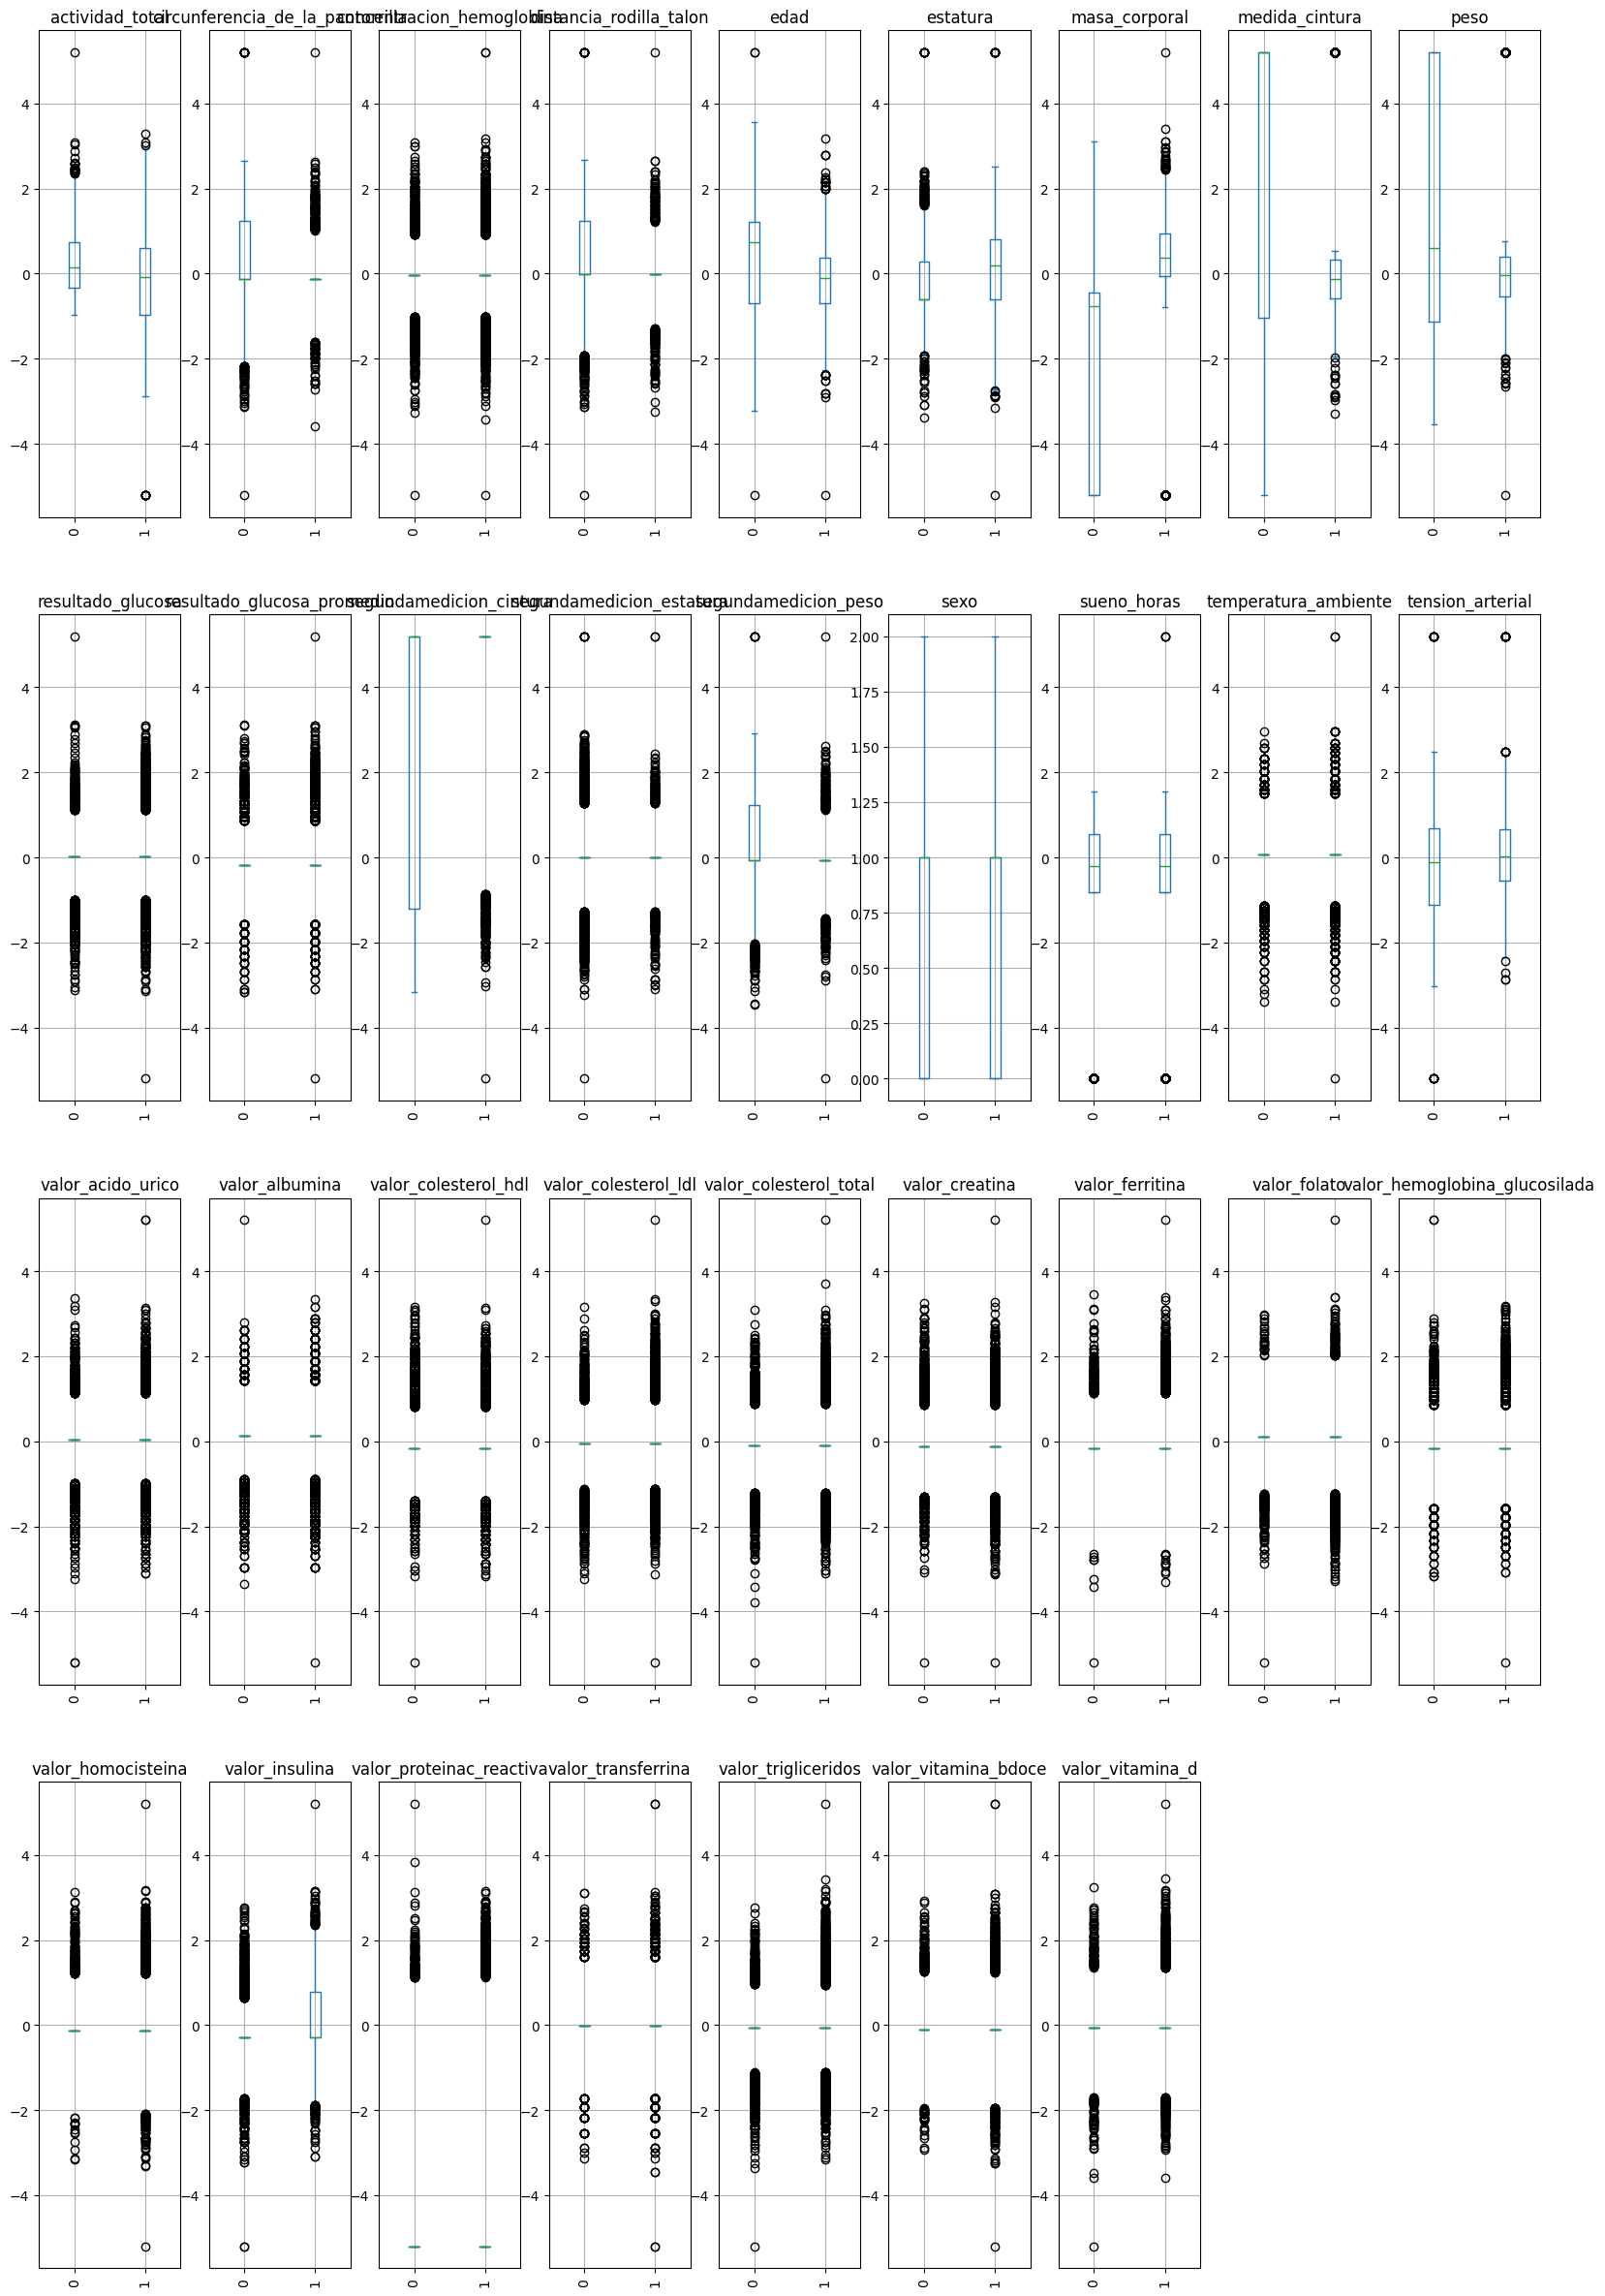

In [ ]:
# merge train set and test set to see overall sample after been transformed
df_transformed =pd.concat([df_train_transformed,df_test_transformed],axis=0)

df_transformed.plot.box(by='riesgo_hipertension',figsize=(20, 30), rot=90, grid= True, layout = (4,9))

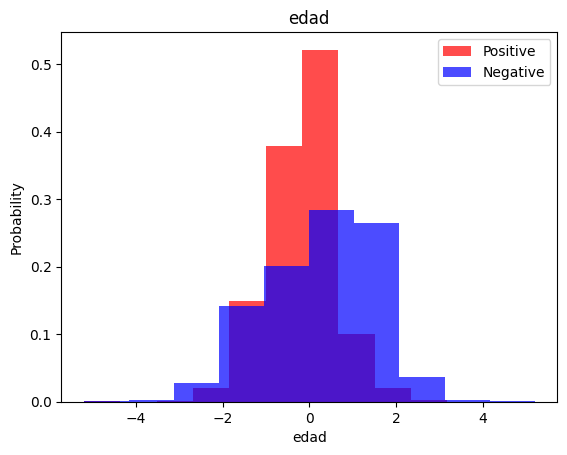

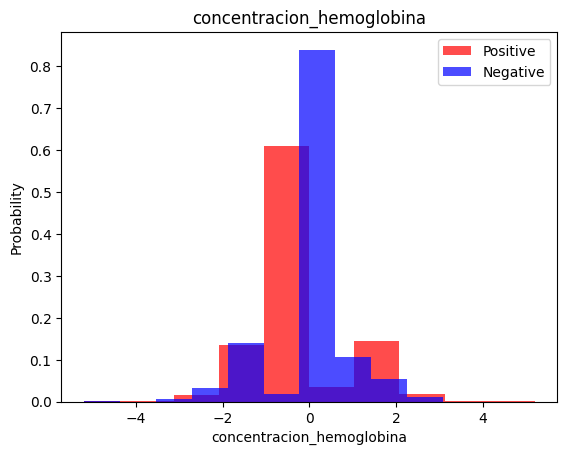

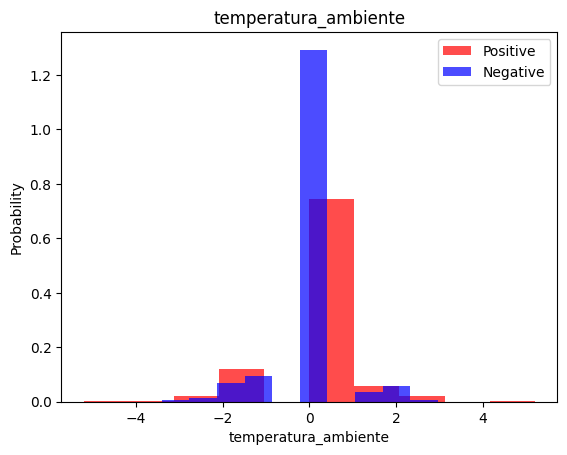

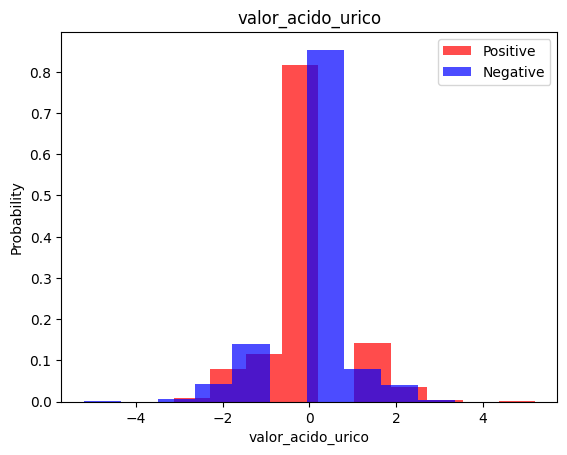

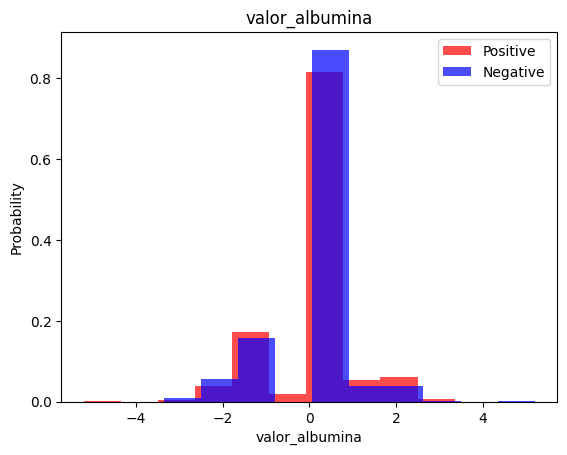

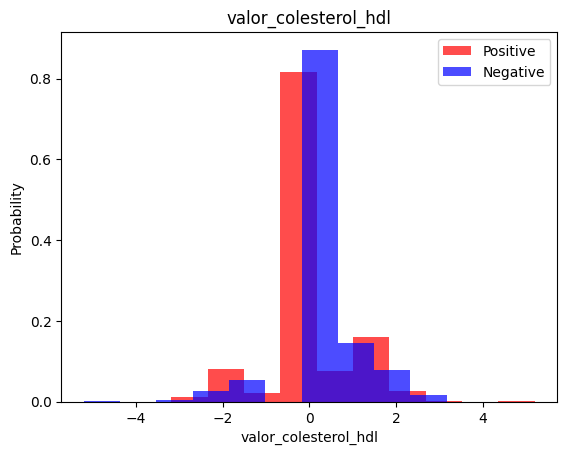

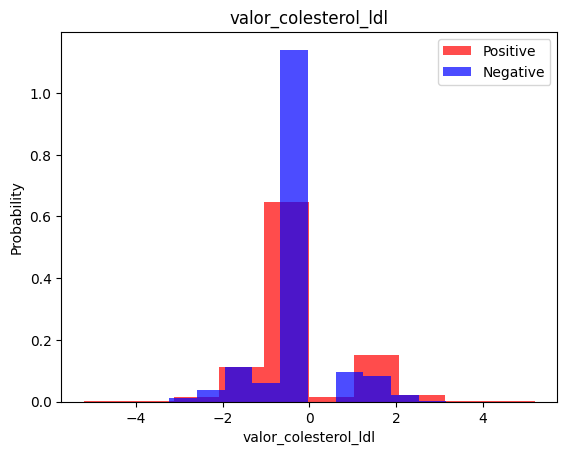

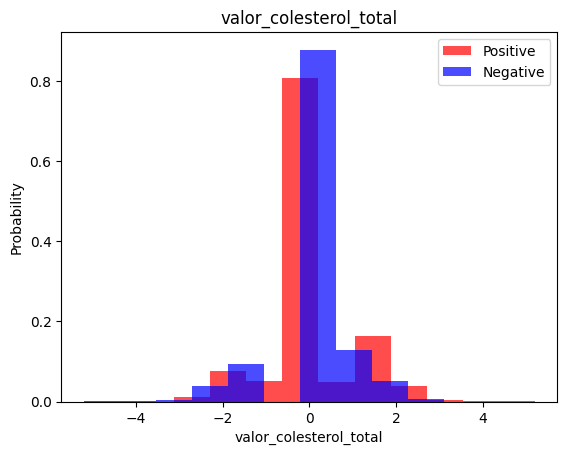

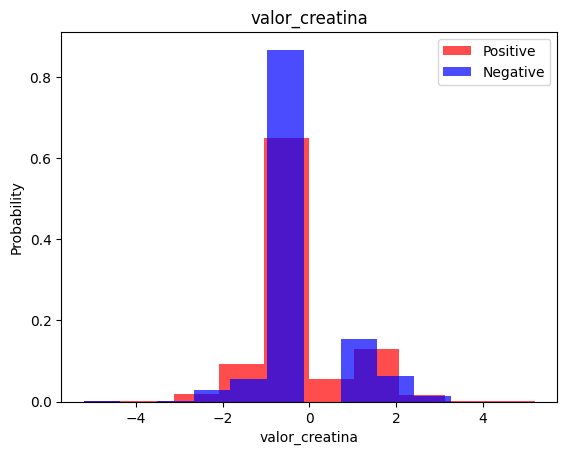

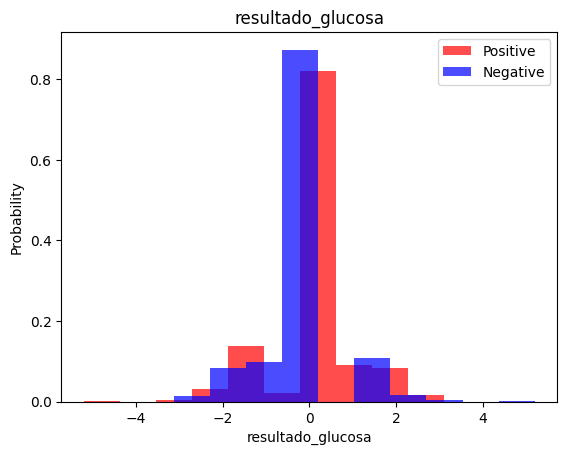

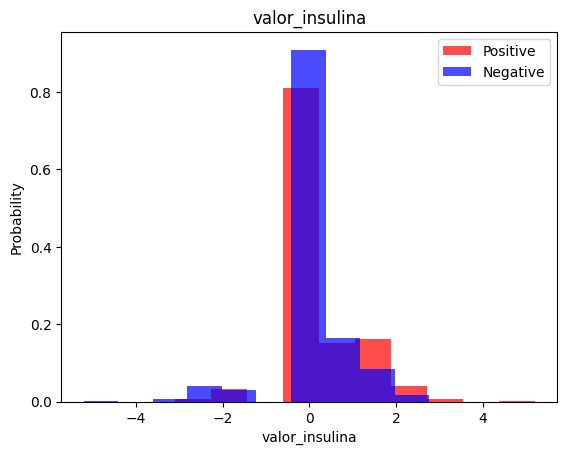

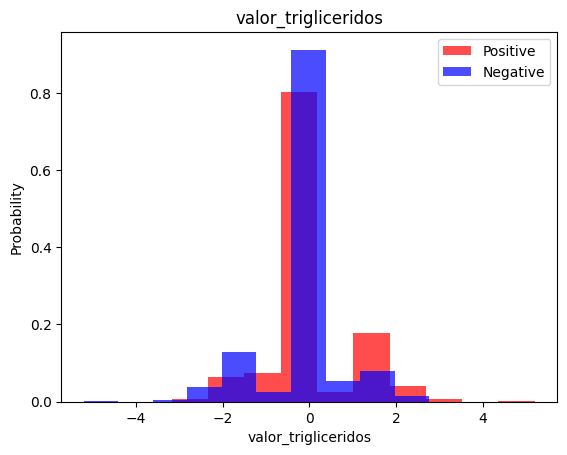

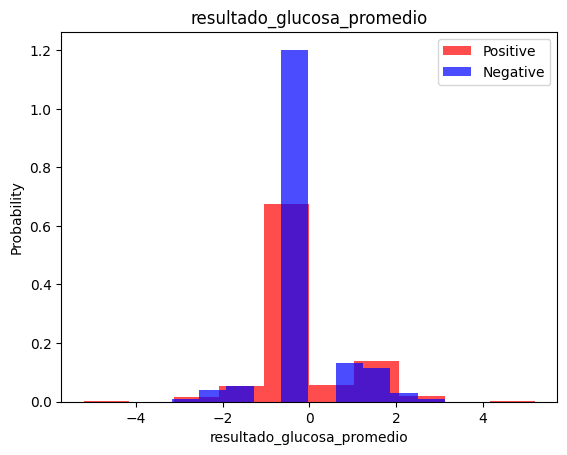

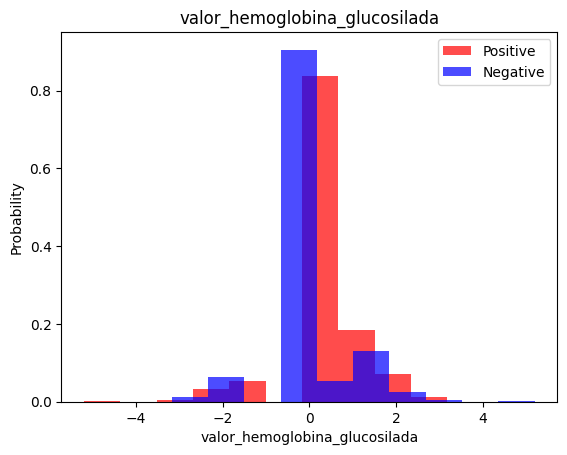

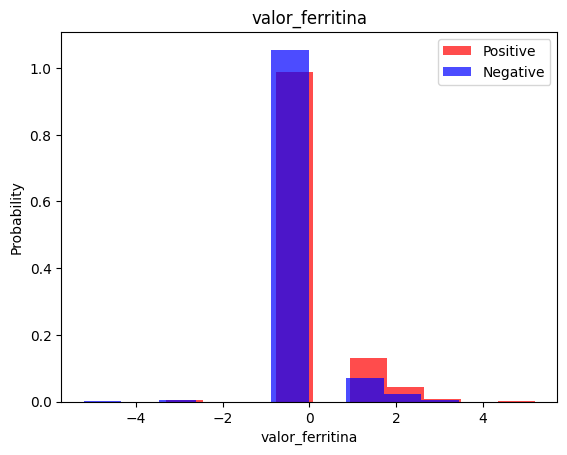

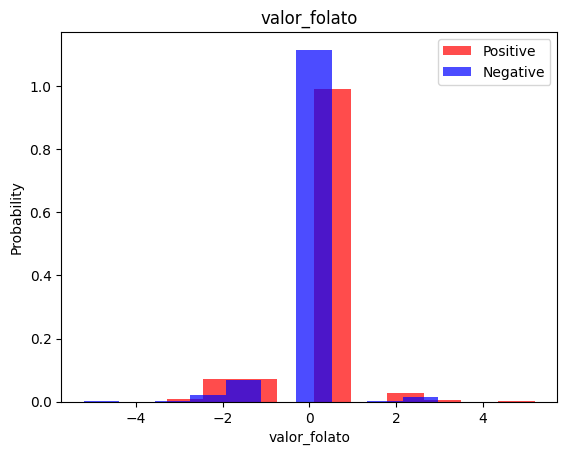

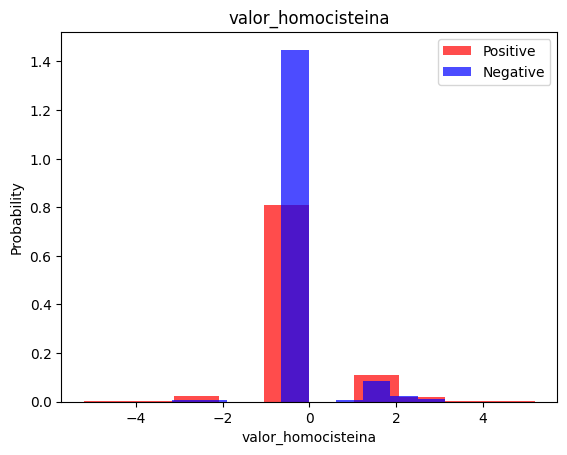

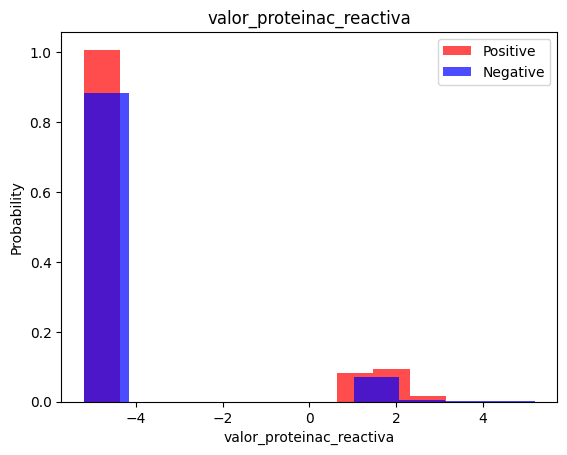

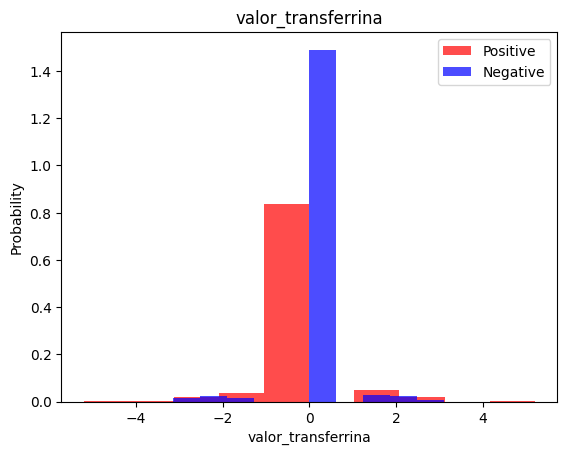

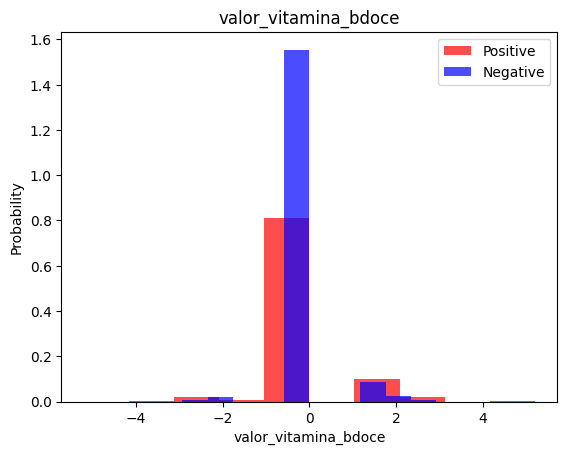

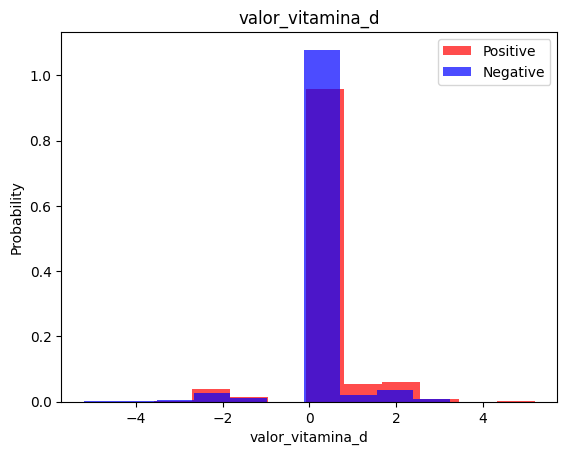

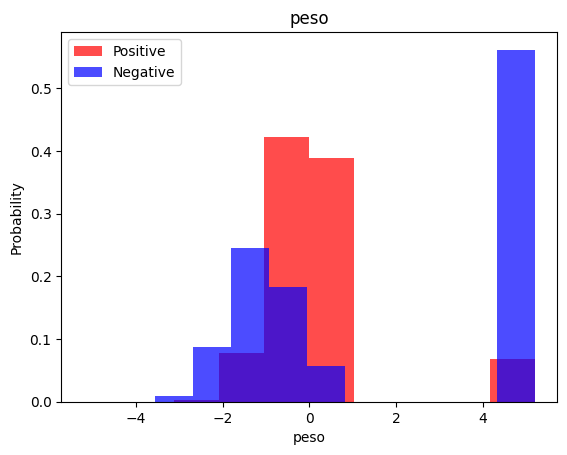

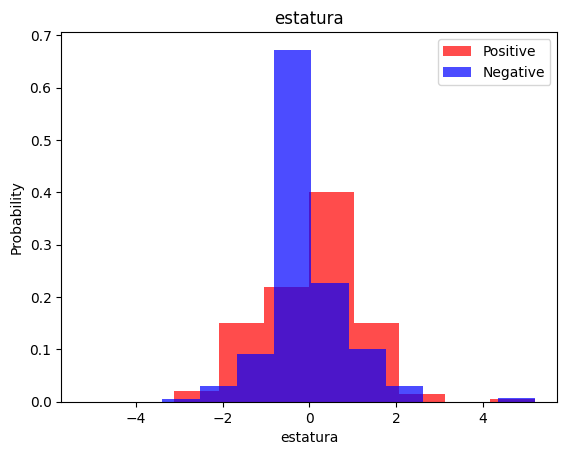

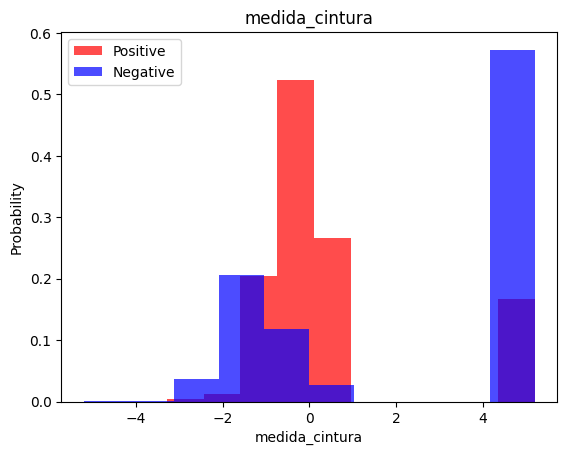

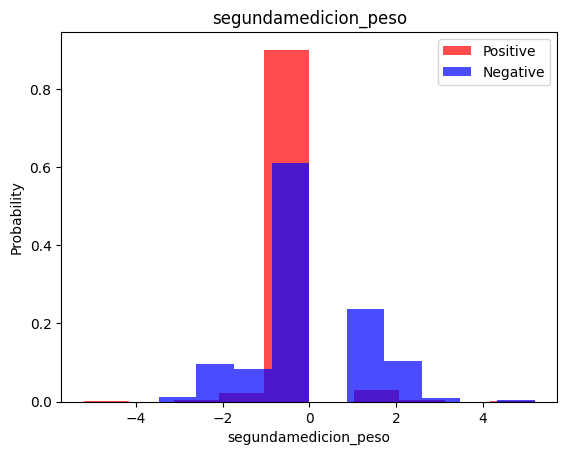

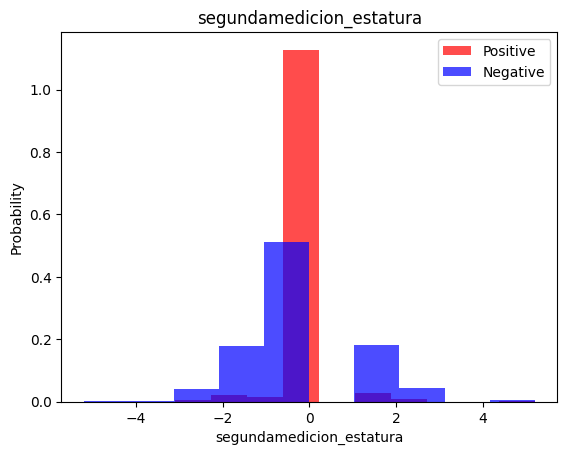

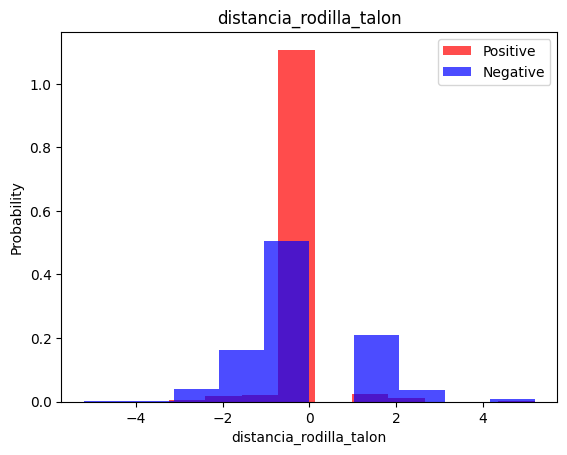

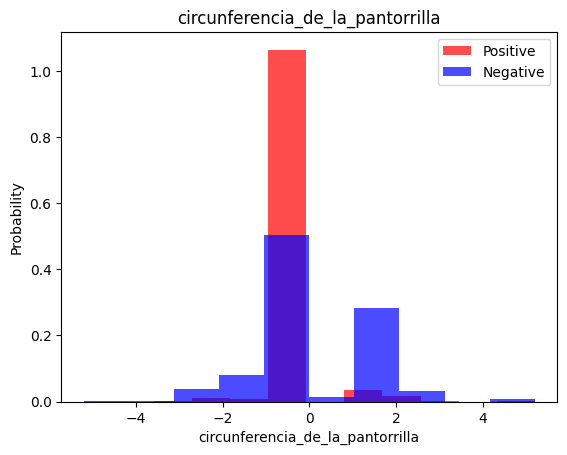

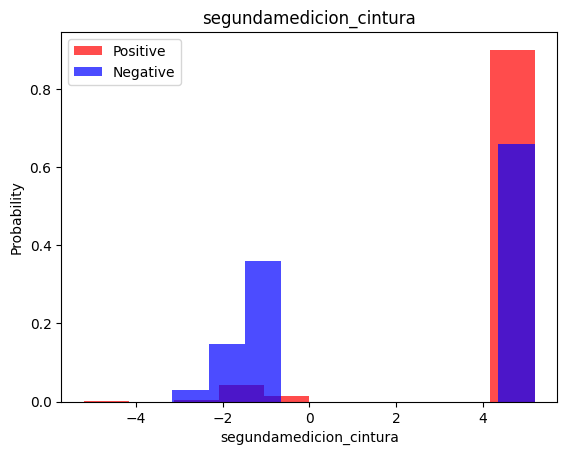

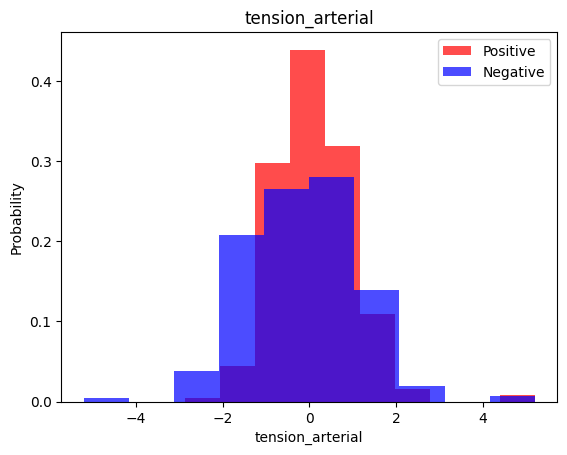

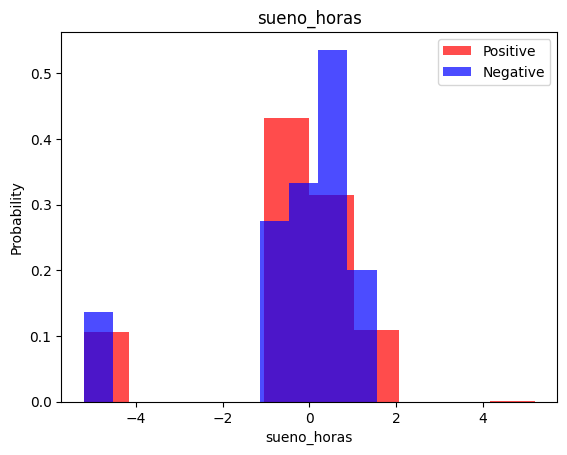

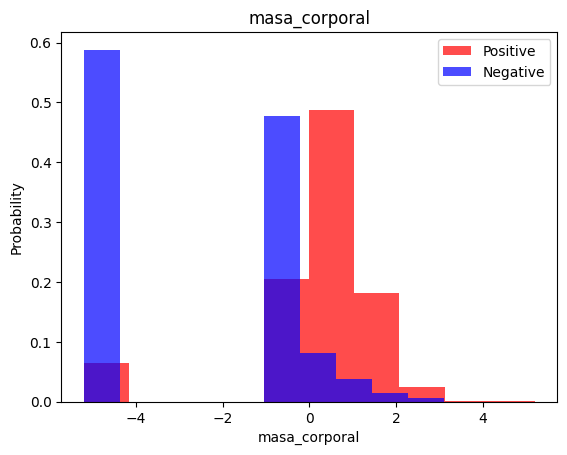

In [ ]:
for col in columns[:-1]:
  plt.hist(df_transformed[df_transformed["riesgo_hipertension"]==1][col], color='red', label='Positive', alpha=0.7, density=True)
  plt.hist(df_transformed[df_transformed["riesgo_hipertension"]==0][col], color='blue', label='Negative', alpha=0.7, density=True)

  plt.title(col)
  plt.ylabel("Probability")
  plt.xlabel(col)
  plt.legend()
  plt.show()

After do QuantileTransformer, amount of outlier data were reduced as much as possible, data distribution shape were less skewed and get closer to the normally distributed shape.

### checking & Prepare data

StandardScaler data

In [ ]:
# seperate train/test set for standardScaler dataset & divide predict feature (X) and target feature (y)
X_std_train, X_std_test, y_std_train, y_std_test = train_test_split(df_standardized.drop(columns=['FOLIO_I','riesgo_hipertension']),
                                                                    df_standardized['riesgo_hipertension'],
                                                                    test_size=0.2,
                                                                    random_state=42)

df_std_train = pd.concat([X_std_train,y_std_train], axis=0)
df_std_test = pd.concat([X_std_test,y_std_test], axis=0)

QuantileTransformer

In [ ]:
# train/test set alredy been seperated
df_train_transformed

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
3902,1.210137,1.114032,-2.696511,-1.817968,-1.292465,1.942703,2.408550,2.074445,1.035790,1.324958,...,-1.312981,-1.625274,-1.654145,-0.231641,-0.195700,-5.199338,0.530745,2022_29007020,1,0
2358,1.025123,1.381364,0.079120,2.325972,-1.761948,1.215372,1.358913,1.100140,2.797301,2.427442,...,1.721914,-1.851734,-1.989660,0.080379,-0.195700,-5.199338,0.138444,2022_17011055,0,1
1936,0.653377,1.079690,0.079120,-0.977487,-1.371657,0.905189,1.223287,1.418119,1.154615,-1.123415,...,-0.016310,-0.124523,5.199338,0.080379,-0.823172,0.457531,0.947580,2022_15033029,1,1
113,-0.232930,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,1.046345,-0.184203,2022_02002048,0,1
2176,-0.523537,1.428482,1.705570,1.798663,2.784622,2.511791,2.063775,2.063775,2.211127,0.030114,...,-0.016310,-0.124523,5.199338,-0.805692,-0.195700,0.620791,0.530745,2022_16019018,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,0.378977,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,-0.599931,1.137677,2022_25006025,0,0
466,-0.032625,1.428482,1.837975,1.494155,0.138444,1.048748,1.202347,1.100140,1.750222,1.324958,...,-0.016310,-0.124523,5.199338,-0.283522,-0.195700,0.621466,-0.184203,2022_05024003,0,1
3092,0.312376,1.517545,0.079120,-1.479004,-1.218002,1.157061,-1.327982,-1.371657,1.084195,1.629992,...,-0.016310,-0.124523,5.199338,1.269664,0.553999,0.982821,1.242061,2022_21114014,1,1
3772,-1.137677,2.107953,1.602210,0.046436,2.225823,1.321946,2.492098,1.936181,1.550085,-1.044409,...,-0.016310,-0.124523,5.199338,0.741388,-0.823172,1.119649,0.090452,2022_27013025,0,1


In [ ]:
df_test_transformed

In [ ]:
# save dataset
df_std_train.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_std_train.csv', index=False)
df_std_test.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_std_test.csv', index=False)
df_train_transformed.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_trans_train.csv', index=False)
df_test_transformed.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_trans_test.csv', index=False)

# Feature Selection - Mutual Information
Calculate Mutual Infomation score (MI score)for feature selection




In [ ]:
from scipy.special import y0
from sklearn.feature_selection import mutual_info_classif, SelectPercentile
import numpy as np

def cal_featureMI_and_noiseMI (X,y,class_features):

  is_discrete = []
  for i in X.columns:
    if i in class_features : is_discrete.append(True)
    else : is_discrete.append(False)

  mi_scores = mutual_info_classif(X, y, random_state=42, discrete_features=is_discrete)

  # make noise data from original dataset, MI scores from this noise dataset will become score baseline
  np.random.seed(42)
  X_permuted = X.copy()
  for col in X.columns:
      X_permuted[col] = np.random.permutation(X_permuted[col].values)

  mi_noise = mutual_info_classif(X_permuted, y, random_state=42, discrete_features=is_discrete)

  # Create DataFrame of feature names, MI scores and score baseline
  mi_df = pd.DataFrame({
      'Feature': X.columns,
      'MI_Score': mi_scores,
      'MI_noise' : mi_noise
  }).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

  return mi_df

### For StandardScaler dataset

In [ ]:
mi_std_df = cal_featureMI_and_noiseMI (X_std_train,y_std_train,['sexo'])
mi_std_df

,Feature,MI_Score,MI_noise
0,masa_corporal,0.321685,0.000000
1,peso,0.241192,0.000000
2,medida_cintura,0.213339,0.000000
3,edad,0.141296,0.000000
4,estatura,0.118264,0.000000
5,segundamedicion_cintura,0.112677,0.000000
6,circunferencia_de_la_pantorrilla,0.111606,0.000294
7,segundamedicion_estatura,0.111055,0.003572
8,distancia_rodilla_talon,0.109493,0.003185
9,segundamedicion_peso,0.108475,0.000000


In [ ]:
selected_std_features = mi_std_df.query('MI_Score > MI_noise')['Feature'].to_list()
print(f'length : {len(selected_std_features)}')
print(selected_std_features)

length : 24
['masa_corporal', 'peso', 'medida_cintura', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'segundamedicion_estatura', 'distancia_rodilla_talon', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_transferrina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_colesterol_total', 'valor_vitamina_d', 'valor_albumina', 'valor_ferritina', 'valor_insulina', 'valor_hemoglobina_glucosilada', 'resultado_glucosa_promedio']


In [ ]:
'''# Optional : selected 50% of feature with highest MI score
selector = SelectPercentile(mutual_info_classif, percentile=50)
selector.fit(X_std, y_std)
top_std_feature = selector.get_feature_names_out(input_features=X_std.columns)
top_std_feature'''

'# Optional : selected 50% of feature with highest MI score\nselector = SelectPercentile(mutual_info_classif, percentile=50)\nselector.fit(X_std, y_std)\ntop_std_feature = selector.get_feature_names_out(input_features=X_std.columns)\ntop_std_feature'

### For QuantileTransformer dataset

In [ ]:
mi_trans_df = cal_featureMI_and_noiseMI (X_trans_train,y_trans_train,['sexo'])
mi_trans_df

,Feature,MI_Score,MI_noise
0,masa_corporal,0.322592,0.000000
1,peso,0.242474,0.000000
2,medida_cintura,0.211972,0.012486
3,edad,0.141990,0.002785
4,estatura,0.117437,0.009266
5,segundamedicion_cintura,0.114316,0.000000
6,circunferencia_de_la_pantorrilla,0.112135,0.000000
7,distancia_rodilla_talon,0.110649,0.000000
8,segundamedicion_estatura,0.110475,0.002766
9,segundamedicion_peso,0.107714,0.000000


In [ ]:
selected_trans_features = mi_trans_df.query('MI_Score > MI_noise')['Feature'].to_list()
print(f'length : {len(selected_trans_features)}')
print(selected_trans_features)

length : 22
['masa_corporal', 'peso', 'medida_cintura', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'distancia_rodilla_talon', 'segundamedicion_estatura', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_transferrina', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumina', 'resultado_glucosa', 'valor_ferritina', 'valor_insulina']


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

def create_redundancy_matrix(X, classifyFeatures):
    features = list(X.columns)
    n_features = len(features)

    is_discrete = []
    for i in features:
      if i in classifyFeatures : is_discrete.append(True)
      else : is_discrete.append(False)

    redundancy_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

    for col in features:
        if col in classifyFeatures:
            redundancy_matrix[col] = mutual_info_classif(
                X, X[col], random_state=42, discrete_features=is_discrete
            )
        else:
            redundancy_matrix[col] = mutual_info_regression(
                X, X[col], random_state=42, discrete_features=is_discrete
            )

    return redundancy_matrix

In [ ]:
# @title
'''import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

def create_jmi_overview_matrix(X, y, classifyF):
    features = list(X.columns)
    n_features = len(features)

    is_discrete = []
    for i in features:
      if i in classifyF : is_discrete.append(True)
      else : is_discrete.append(False)

    mi_target = mutual_info_classif(X, y, random_state=42,  discrete_features=is_discrete)
    relevance_df = pd.DataFrame({
        'Feature': features,
        'Relevance_Score': mi_target
    }).sort_values(by='Relevance_Score', ascending=False).reset_index(drop=True)

    redundancy_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

    for col in features:
        if col in classifyF:
            redundancy_matrix[col] = mutual_info_classif(
                X, X[col], random_state=42, discrete_features=is_discrete
            )
        else:
            redundancy_matrix[col] = mutual_info_regression(
                X, X[col], random_state=42, discrete_features=is_discrete
            )

    jmi_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

    for i, f1 in enumerate(features):
        for j, f2 in enumerate(features):
            if f1 == f2:
                jmi_matrix.loc[f1, f2] = mi_target[i]
            else:
                jmi_score = mi_target[i] + mi_target[j] - redundancy_matrix.loc[f1, f2]
                jmi_matrix.loc[f1, f2] = max(0, jmi_score)

    return relevance_df, redundancy_matrix, jmi_matrix

relevance_std_df, redundancy_std_df, jmi_std_df = create_jmi_overview_matrix(X_std, y_std, ['sexo'])
relevance_trans_df, redundancy_trans_df, jmi_trans_df = create_jmi_overview_matrix(X_trans, y_trans, ['sexo'])
'''

"import numpy as np\nimport pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom sklearn.feature_selection import mutual_info_classif, mutual_info_regression\n\ndef create_jmi_overview_matrix(X, y, classifyF):\n    features = list(X.columns)\n    n_features = len(features)\n\n    is_discrete = []\n    for i in features:\n      if i in classifyF : is_discrete.append(True)\n      else : is_discrete.append(False)\n\n    mi_target = mutual_info_classif(X, y, random_state=42,  discrete_features=is_discrete)\n    relevance_df = pd.DataFrame({\n        'Feature': features,\n        'Relevance_Score': mi_target\n    }).sort_values(by='Relevance_Score', ascending=False).reset_index(drop=True)\n\n    redundancy_matrix = pd.DataFrame(index=features, columns=features, dtype=float)\n\n    for col in features:\n        if col in classifyF:\n            redundancy_matrix[col] = mutual_info_classif(\n                X, X[col], random_state=42, discrete_features=is_discrete\n     

In [ ]:
def remove_redundancy_feature (redundancy_matrix,baseline_selected_features, mi_score_df) :
  # for redundancy_matrix, cut-off features that have lower MI score than noise baseline first
  redundancy_std_MIfilter = redundancy_matrix[baseline_selected_features]
  cutout_feature = []

  # remove redundancy feature with less MI score or same MI score
  for i in baseline_selected_features :
    if i not in cutout_feature :
      redundancy_list = redundancy_std_MIfilter.index[redundancy_std_MIfilter[i] >= 0.70].tolist()

      if i in redundancy_list : redundancy_list.remove(i)

      current = mi_score_df.loc[mi_score_df['Feature'] == i, ['Feature','MI_Score']].iloc[0]
      redundance = mi_score_df.query(f"Feature in {redundancy_list}")
      redundance_mi_score = redundance['MI_Score'].tolist()

      if not redundance_mi_score == [] :
        if current['MI_Score'] < max(redundance_mi_score) :
          cutout_feature.append(current['Feature'])
        elif current['MI_Score'] == max(redundance_mi_score) :
          cutout_feature.append(redundance.loc[redundance['MI_Score'] == current['MI_Score']]['Feature'])

    else :
      continue

  # get remain feature
  remove_redun_features = [select for select in baseline_selected_features if select not in cutout_feature]

  return remove_redun_features

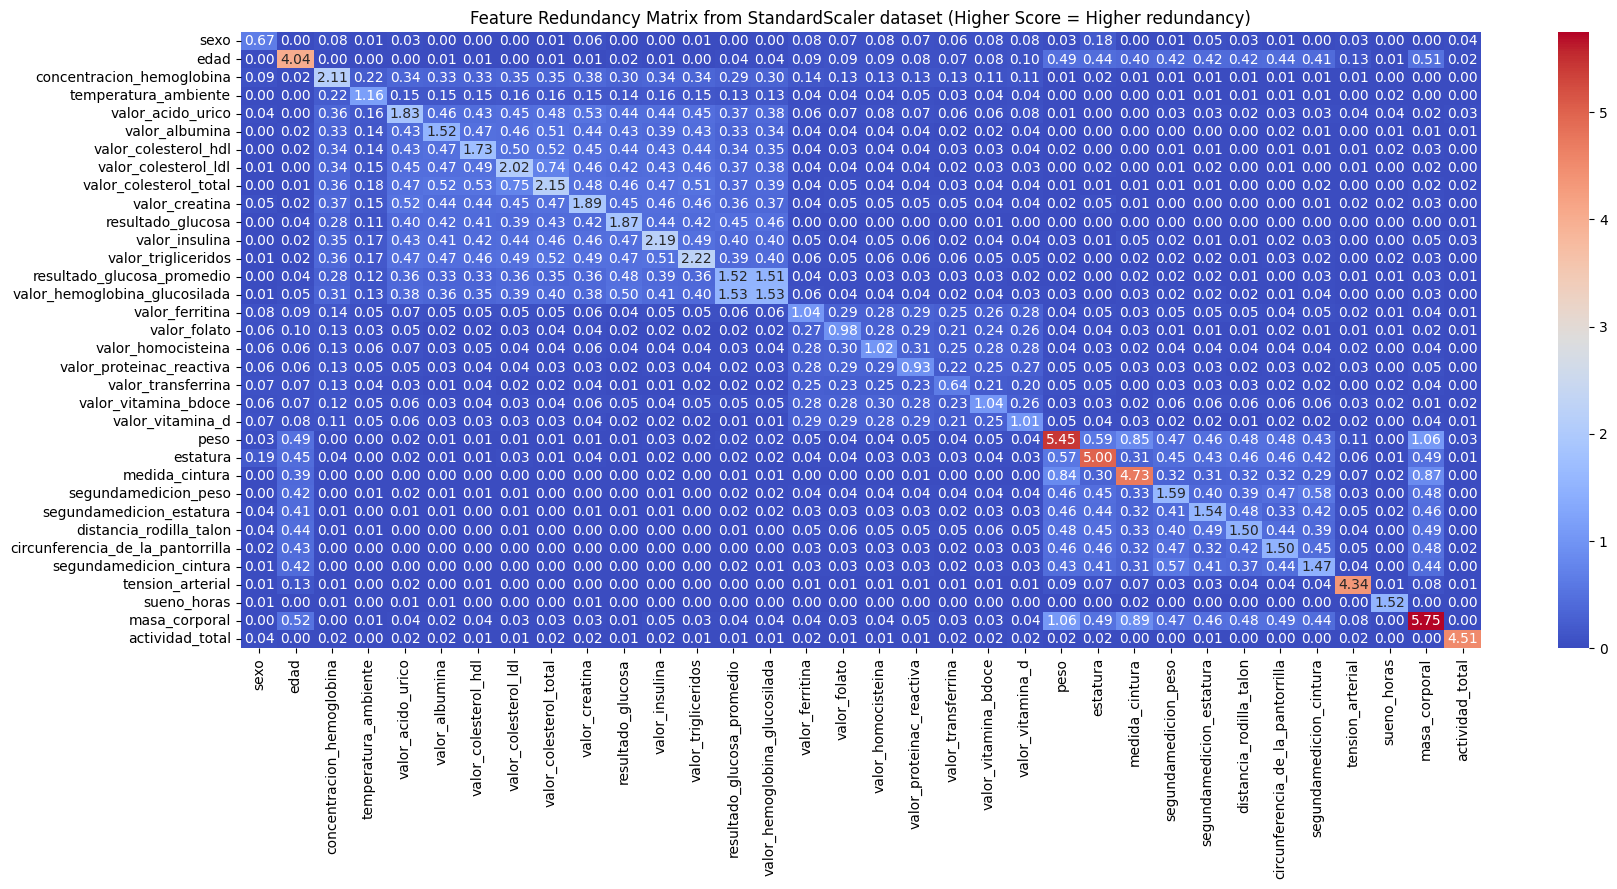

In [ ]:
# calculate redundancy matrix of StandardScelar data
redundancy_std_matrix = create_redundancy_matrix(X_std_train , ['sexo'])

plt.figure(figsize=(20, 8))
sns.heatmap(redundancy_std_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Redundancy Matrix from StandardScaler dataset (Higher Score = Higher redundancy)")
plt.show()

In [ ]:
# removing redundancy feature for StandardScelar data
std_no_redun_feature = remove_redundancy_feature(redundancy_std_matrix,selected_std_features, mi_std_df)

print('Feature amount (select from StandardScelar data)')
print(f'before remove redundancy : {len(selected_std_features)}')
print(selected_std_features)

print(f'after remove redundancy : {len(std_no_redun_feature)}')
print(std_no_redun_feature)

Feature amount (select from StandardScelar data)
before remove redundancy : 24
['masa_corporal', 'peso', 'medida_cintura', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'segundamedicion_estatura', 'distancia_rodilla_talon', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_transferrina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_colesterol_total', 'valor_vitamina_d', 'valor_albumina', 'valor_ferritina', 'valor_insulina', 'valor_hemoglobina_glucosilada', 'resultado_glucosa_promedio']
after remove redundancy : 20
['masa_corporal', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'segundamedicion_estatura', 'distancia_rodilla_talon', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_transferrina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumin

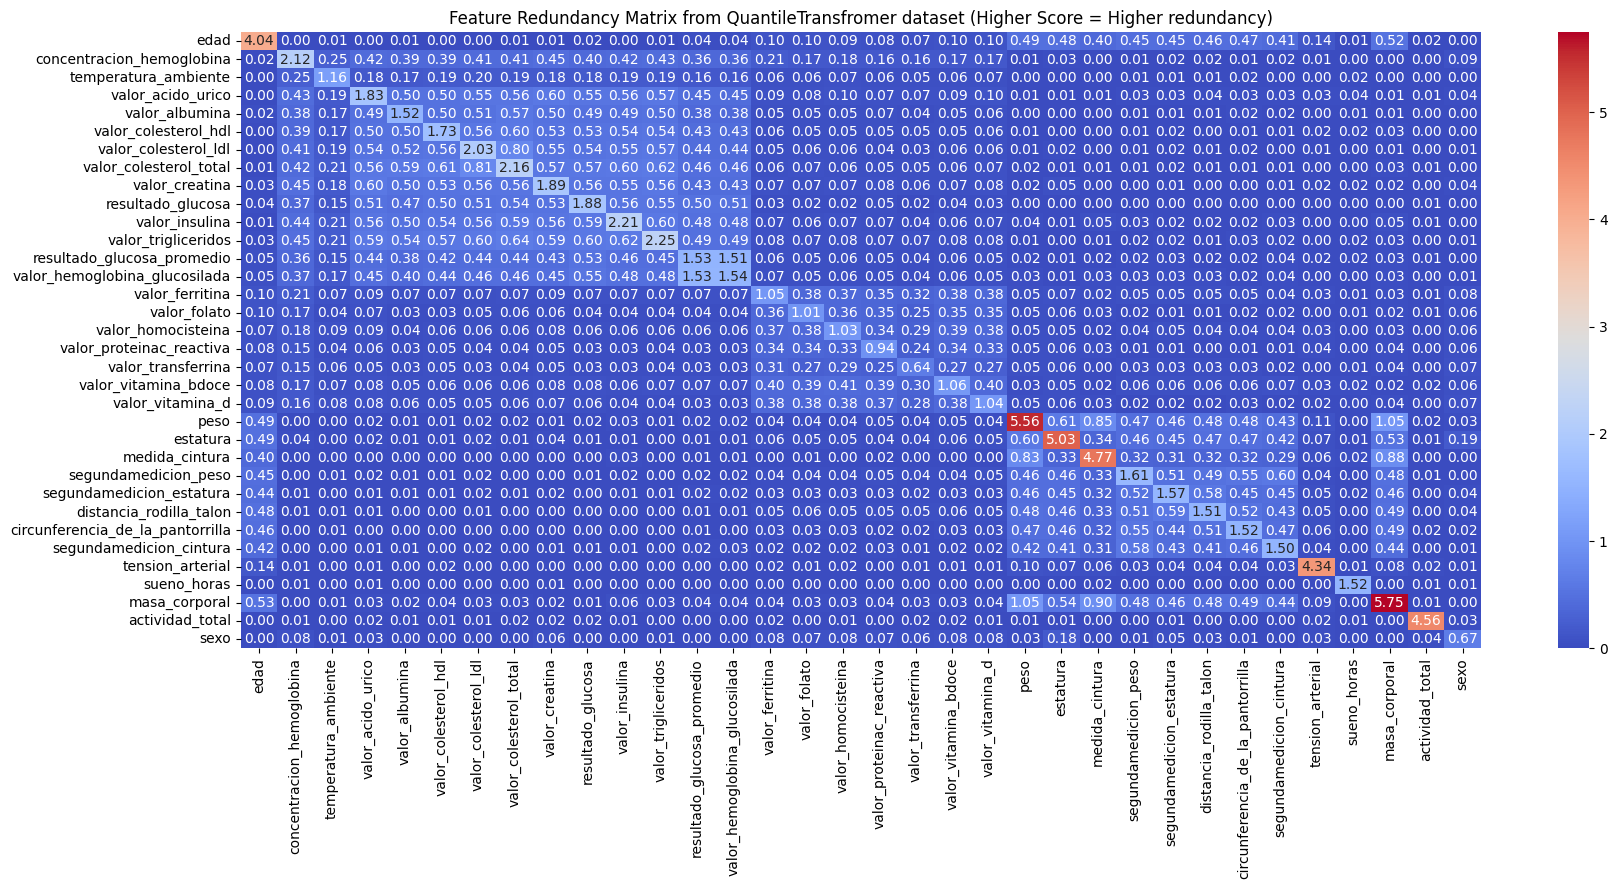

In [ ]:
# calculate redundancy matrix of QuantileTransformer data
redundancy_trans_matrix = create_redundancy_matrix(X_trans_train , ['sexo'])

plt.figure(figsize=(20, 8))
sns.heatmap(redundancy_trans_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Redundancy Matrix from QuantileTransfromer dataset (Higher Score = Higher redundancy)")
plt.show()

In [ ]:
# removing redundancy feature for QuantileTransformer data
trans_no_redun_feature = remove_redundancy_feature(redundancy_trans_matrix,selected_trans_features, mi_std_df)

print('Feature amount (select from QuantileTransformer data)')
print(f'before remove redundancy : {len(selected_trans_features)}')
print(selected_trans_features)

print(f'after remove redundancy : {len(trans_no_redun_feature)}')
print(trans_no_redun_feature)

Feature amount (select from QuantileTransformer data)
before remove redundancy : 22
['masa_corporal', 'peso', 'medida_cintura', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'distancia_rodilla_talon', 'segundamedicion_estatura', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_transferrina', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumina', 'resultado_glucosa', 'valor_ferritina', 'valor_insulina']
after remove redundancy : 20
['masa_corporal', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'distancia_rodilla_talon', 'segundamedicion_estatura', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_transferrina', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumina', 'resultado_glucosa', 'valor_ferritina', 'valor_insulina']
